# ICBC Road Safety Analysis — Exploratory Data Analysis
**Data:** ICBC crash records 2020–2024 (~1.37M rows)

| # | Section |
|---|---------|
| 0 | Imports & Setup |
| 1 | Load & Validate |
| 2 | Dataset Overview |
| 3 | RQ1 — Temporal: Year, Month, Season, Day, Hour |
| 4 | RQ1 — Crash Configuration & Road Location |
| 5 | RQ1 — Intersection & Parking Analysis |
| 6 | RQ3 — Vulnerability Gap Trend (2020–2024) |
| 7 | RQ3 — Relative Index of Inequality (RII) |
| 8 | RQ4 — Municipal Geography |
| 9 | Cross-Dimensional Analysis |
| 10 | Summary of Key Findings |


## Introduction

This notebook presents exploratory data analysis of the cleaned ICBC crash dataset 
produced by `01_icbc_data_pipeline.ipynb`. The goal is to surface patterns and 
quantify inequalities that directly address the four research questions of this project. 
Analysis is structured around three dimensions: temporal variation in crash frequency 
and severity (RQ1), the injury risk gap between vulnerable road users — pedestrians, 
cyclists, and motorcyclists — and car occupants across 2020–2024 (RQ3), and geographic 
concentration of vulnerable-user casualties at the municipality level (RQ4). All 
visualizations are saved to the `output/` directory for use in the final report and 
dashboard. Findings from each section are summarized at the end of the notebook.

## 0. Imports & Setup

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.4,
})

# Palette
C_BLUE    = "#2E75B6"
C_RED     = "#C0392B"
C_ORANGE  = "#E67E22"
C_GREEN   = "#27AE60"
C_PURPLE  = "#8E44AD"
C_GREY    = "#7F8C8D"
C_TEAL    = "#16A085"
C_YELLOW  = "#F1C40F"

VULN_PAL  = {"Pedestrian": C_RED, "Cyclist": C_ORANGE, "Motorcyclist": C_PURPLE,
             "Heavy Vehicle": C_TEAL, "Car Occupant": C_BLUE}

INPUT_CSV  = "output/icbc_cleaned_enriched.csv"
OUTPUT_DIR = "output"


## 1. Load & Validate

In [159]:
df = pd.read_csv(INPUT_CSV, low_memory=False)

for col in ["year","month","hour_approx","is_casualty","is_vulnerable",
            "intersection","flag_cyclist","flag_pedestrian","flag_motorcycle","flag_heavy_veh"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Normalise string columns
for col in ["day_of_week","season","road_user_type","crash_config",
            "road_location","municipality","severity_raw"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print(f"Shape          : {df.shape}")
print(f"Years          : {sorted(df['year'].dropna().unique().astype(int).tolist())}")
print(f"Columns        : {list(df.columns)}")
display(df.head(3))


Shape          : (1368385, 38)
Years          : [2020, 2021, 2022, 2023, 2024]
Columns        : ['crash_breakdown', 'year', 'flag_animal', 'severity', 'flag_cyclist', 'day_of_week', 'crash_config', 'flag_heavy_veh', 'intersection', 'month', 'flag_motorcycle', 'municipality', 'flag_parked_vehicle', 'flag_parking_lot', 'flag_pedestrian', 'region', 'road_location', 'street', 'time_category', 'municipality_raw', 'street_raw', 'metric_selector', 'total_crashes', 'total_victims', 'severity_raw', 'severity_ord', 'is_casualty', 'is_fatal', 'road_user_type', 'is_vulnerable', 'season', 'hour_approx', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_num', 'is_weekend']


,crash_breakdown,year,flag_animal,severity,flag_cyclist,day_of_week,crash_config,flag_heavy_veh,intersection,month,...,road_user_type,is_vulnerable,season,hour_approx,hour_sin,hour_cos,month_sin,month_cos,dow_num,is_weekend
0,DELTA,2020,0,CASUALTY CRASH,0,FRIDAY,REAR END,0,0,1.0,...,Car Occupant,0,Winter,16,-0.866025,-0.500000,5.000000e-01,0.866025,4,0
1,MISSION,2020,0,CASUALTY CRASH,0,MONDAY,CONFLICTED,0,0,7.0,...,Car Occupant,0,Summer,16,-0.866025,-0.500000,-5.000000e-01,-0.866025,0,0
2,ABBOTSFORD,2020,0,CASUALTY CRASH,0,MONDAY,SINGLE VEHICLE,0,0,12.0,...,Car Occupant,0,Winter,19,-0.965926,0.258819,-2.449294e-16,1.000000,0,0


## 2. Dataset Overview

In [161]:
total    = len(df)
cas_n    = int(df["is_casualty"].sum())
vuln_n   = int(df["is_vulnerable"].sum())
years    = sorted(df["year"].dropna().unique().astype(int))

stats = {
    "Total crash records":               f"{total:,.0f}",
    "Casualty crashes":                   f"{cas_n:,.0f} ({cas_n/total*100:.1f}%)",
    "PDO crashes":                        f"{total-cas_n:,.0f} ({(total-cas_n)/total*100:.1f}%)",
    "Year range":                         f"{years[0]} – {years[-1]}",
    "Unique municipalities":              f"{df['municipality'].nunique():,}",
    "Vulnerable-user crashes":            f"{vuln_n:,.0f} ({vuln_n/total*100:.1f}%)",
    "Vulnerable casualty rate":           f"{df[df['is_vulnerable']==1]['is_casualty'].mean()*100:.1f}%",
    "Non-vulnerable casualty rate":       f"{df[df['is_vulnerable']==0]['is_casualty'].mean()*100:.1f}%",
    "Weekend crashes":                    f"{df['is_weekend'].sum():,.0f} ({df['is_weekend'].mean()*100:.1f}%)" if "is_weekend" in df.columns else "N/A",
    "Intersection crashes":               f"{df['intersection'].sum():,.0f} ({df['intersection'].mean()*100:.1f}%)",
}
display(pd.DataFrame(list(stats.items()), columns=["Metric","Value"]).style.hide(axis="index"))


Metric,Value
Total crash records,"1,368,385"
Casualty crashes,"244,216 (17.8%)"
PDO crashes,"1,124,169 (82.2%)"
Year range,2020 – 2024
Unique municipalities,846
Vulnerable-user crashes,"37,413 (2.7%)"
Vulnerable casualty rate,67.9%
Non-vulnerable casualty rate,16.4%
Weekend crashes,"323,633 (23.7%)"
Intersection crashes,"563,396 (41.2%)"


The core thesis is confirmed right here.
Vulnerable users make up only 2.7% of crashes but have a 67.9% casualty rate vs 16.4% for non-vulnerable. That's a **4.1× multiplier**.

**PDO dominates (82.2%)** — most crashes in BC result in no injury, just property damage. The 17.8% casualty rate is the baseline to beat for every subgroup analysis.

**Weekend crashes (23.7%)** — Only 23.7% of crashes happen on weekends. This means weekdays actually have more crashes (commuting volume), but we expect weekend casualty rates to be higher (speeding, impairment). Worth watching later.

**Intersection crashes (41.2%)** — nearly half of all crashes happen at intersections, which sets up an important question: do intersections produce higher or lower casualty rates? (Intuition says lower — speeds are reduced, but conflict points are higher.)

**Note** – 846 unique municipalities is a lot — likely includes very small or rural entries with just 1–2 crashes. When we get to RQ4, the minimum crash threshold filter (e.g. 200) will clean this up to meaningful entries only.

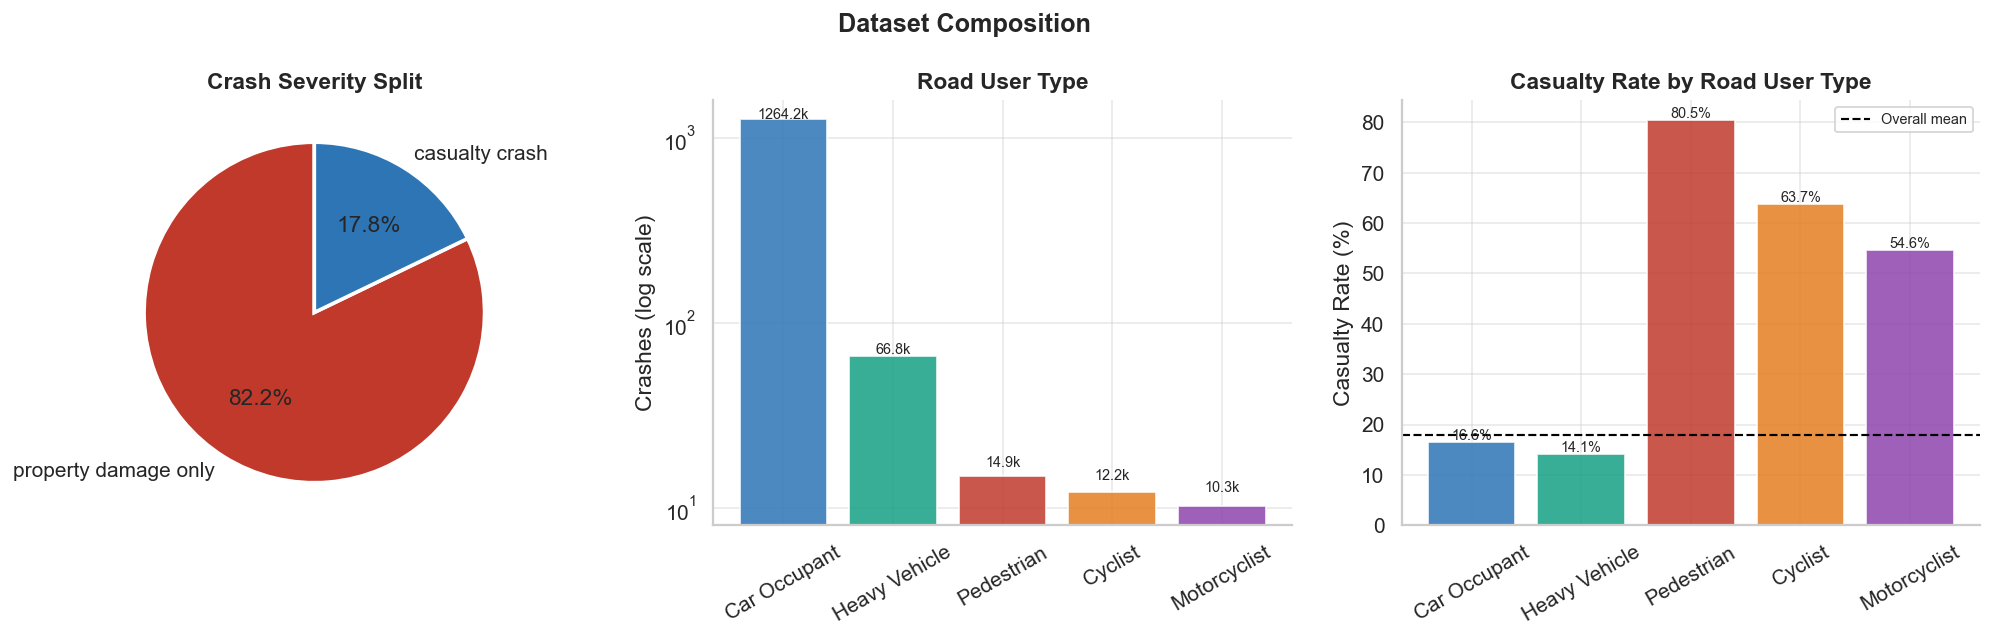

In [163]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dataset Composition", fontsize=14, fontweight="bold")

# Pie: Severity split (works fine because we have roughly 80/20)
sev_counts = df["severity_raw"].value_counts()
axes[0].pie(sev_counts, labels=sev_counts.index, autopct="%1.1f%%",
            colors=[C_RED, C_BLUE], startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":2})
axes[0].set_title("Crash Severity Split", fontweight="bold")

# Bar: Road user type
rut_counts = df["road_user_type"].value_counts()
colors_rut = [VULN_PAL.get(r, C_GREY) for r in rut_counts.index]
bars = axes[1].bar(rut_counts.index, rut_counts.values / 1000, color=colors_rut, alpha=0.85)
axes[1].set_title("Road User Type", fontweight="bold")
axes[1].set_yscale("log")
axes[1].set_ylabel("Crashes (log scale)")
axes[1].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, rut_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f"{val/1000:.1f}k", ha="center", fontsize=8)

# Bar: Casualty rate by road user type
rut_rates = (df.groupby("road_user_type")["is_casualty"].mean() * 100).reindex(rut_counts.index)
colors_rate = [VULN_PAL.get(r, C_GREY) for r in rut_rates.index]
bars2 = axes[2].bar(rut_rates.index, rut_rates.values, color=colors_rate, alpha=0.85)
axes[2].axhline(df["is_casualty"].mean()*100, color="black", ls="--", lw=1.2, label="Overall mean")
axes[2].set_title("Casualty Rate by Road User Type", fontweight="bold")
axes[2].set_ylabel("Casualty Rate (%)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend(fontsize=8)
for bar, val in zip(bars2, rut_rates.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/overview_composition.png", bbox_inches="tight")
plt.show()

#### Road User Type Volume (Middle):
How many crashes there are?

Car Occupants dominate at 1,264k crashes — 92.4% of all crashes, expected since BC roads are car-centric
Vulnerable users combined: Pedestrian 14.9k + Cyclist 12.2k + Motorcyclist 10.3k = ~37k total (2.7%)
Heavy Vehicle at 66.8k is notable — relatively high volume, but as we'll see their casualty rate is low

**Note**: The log scale here is intentional — the raw count difference between car occupants and vulnerable users is so extreme (~120×) that a linear scale hides the vulnerable user data entirely.

#### Casualty Rate by Road User Type (Right):
When a crash does happen, how likely is it to hurt someone?
This is the most important chart in the entire project.

**Causalty Rate** – Out of every 100 crashes involving that road user type, how many resulted in at least one injury (casualty crash vs PDO).

Pedestrian: 80.5% — 4 in 5 pedestrian crashes result in injury. Highest of all groups.
Cyclist: 63.7% — nearly 2 in 3 cyclist crashes result in injury
Motorcyclist: 54.6% — over half
Car Occupant: 16.6% — baseline, protected by steel frame + airbags
Heavy Vehicle: 14.1% — lowest, which makes sense (truck drivers are well-protected)
Overall mean (dashed): ~17.8% — Car Occupant and Heavy Vehicle are the only groups below the mean

**Note:** Despite representing only 2.7% of crashes, vulnerable users face casualty rates 3–5× higher than car occupants. This directly supports the thesis that road infrastructure systematically disadvantages unprotected users. The gap between the dashed line and the vulnerable user bars is the visual proof of structural inequality.

When a vulnerable user is involved in a crash, it almost always results in injury. When a car occupant is involved, it usually doesn't.


---
## 3. RQ1 — Temporal Patterns


### 3.1 Year-over-Year Crash Trends

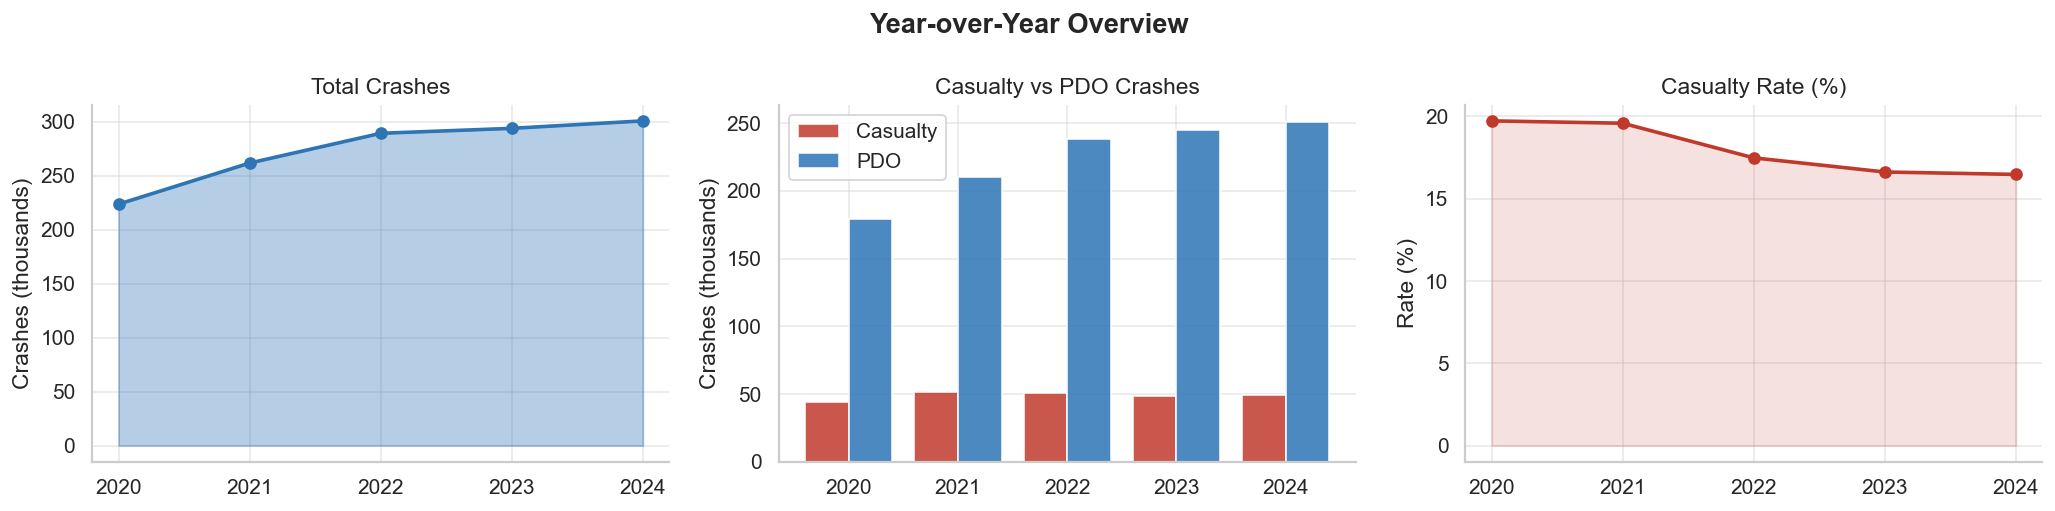

In [167]:
yr = (df.groupby("year")
      .agg(crashes=("is_casualty","count"), casualties=("is_casualty","sum"))
      .assign(casualty_rate=lambda x: x["casualties"]/x["crashes"]*100,
              pdo=lambda x: x["crashes"]-x["casualties"])
      .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Year-over-Year Overview", fontweight="bold")

axes[0].fill_between(yr["year"], yr["crashes"]/1000, alpha=0.35, color=C_BLUE)
axes[0].plot(yr["year"], yr["crashes"]/1000, marker="o", color=C_BLUE, lw=2)
axes[0].set_title("Total Crashes")
axes[0].set_ylabel("Crashes (thousands)")
axes[0].set_xticks(yr["year"])

x = np.arange(len(yr))
axes[1].bar(x-0.2, yr["casualties"]/1000, 0.4, color=C_RED, label="Casualty", alpha=0.85)
axes[1].bar(x+0.2, yr["pdo"]/1000, 0.4, color=C_BLUE, label="PDO", alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(yr["year"].astype(int))
axes[1].set_title("Casualty vs PDO Crashes")
axes[1].set_ylabel("Crashes (thousands)")
axes[1].legend()

axes[2].plot(yr["year"], yr["casualty_rate"], marker="o", color=C_RED, lw=2)
axes[2].fill_between(yr["year"], yr["casualty_rate"], alpha=0.15, color=C_RED)
axes[2].set_title("Casualty Rate (%)")
axes[2].set_ylabel("Rate (%)")
axes[2].set_xticks(yr["year"])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq1_year.png", bbox_inches="tight")
plt.show()


#### Chart 1 — Total Crashes (rising):

Steady increase from ~220k (2020) to ~300k (2024)
2020 is the obvious outlier low — COVID lockdowns reduced traffic volume significantly
The rise post-2020 reflects traffic returning to normal + population/vehicle growth in BC

#### Chart 2 — Casualty vs PDO:

PDO (blue) is driving all the growth — from ~175k to ~250k
Casualty crashes (red) stayed nearly flat — roughly 45–50k every year
This is actually a positive signal: more cars on the road but not proportionally more injuries

#### Chart 3 — Casualty Rate (declining):

Dropped from ~20% in 2020 down to ~16.5% in 2024
This is the most important trend here

**Why did the rate drop?** Two possible explanations:

Real improvement — safer roads, better enforcement, vehicle safety tech (automatic braking etc.)
Composition shift — post-COVID, more low-speed urban fender-benders (PDO) were reported as traffic recovered, diluting the rate

The truth is likely both. We can't confirm which without deeper data.

Result: Total crashes rose 36% from 2020–2024, driven entirely by PDO growth. Casualty crashes remained flat, causing the casualty rate to decline from 20% → 16.5%. This suggests road safety may be gradually improving in BC, though 2020's COVID effect makes the trend hard to interpret cleanly.

### 3.2 Monthly Patterns

In [170]:
print(df["month"].dtype)
print(df["month"].value_counts().head(10))
print(df["month"].isna().sum())

float64
month
12.0    128496
11.0    122900
7.0     121147
10.0    120695
1.0     119745
8.0     117538
9.0     116046
6.0     113786
5.0     107805
2.0     102462
Name: count, dtype: int64
0


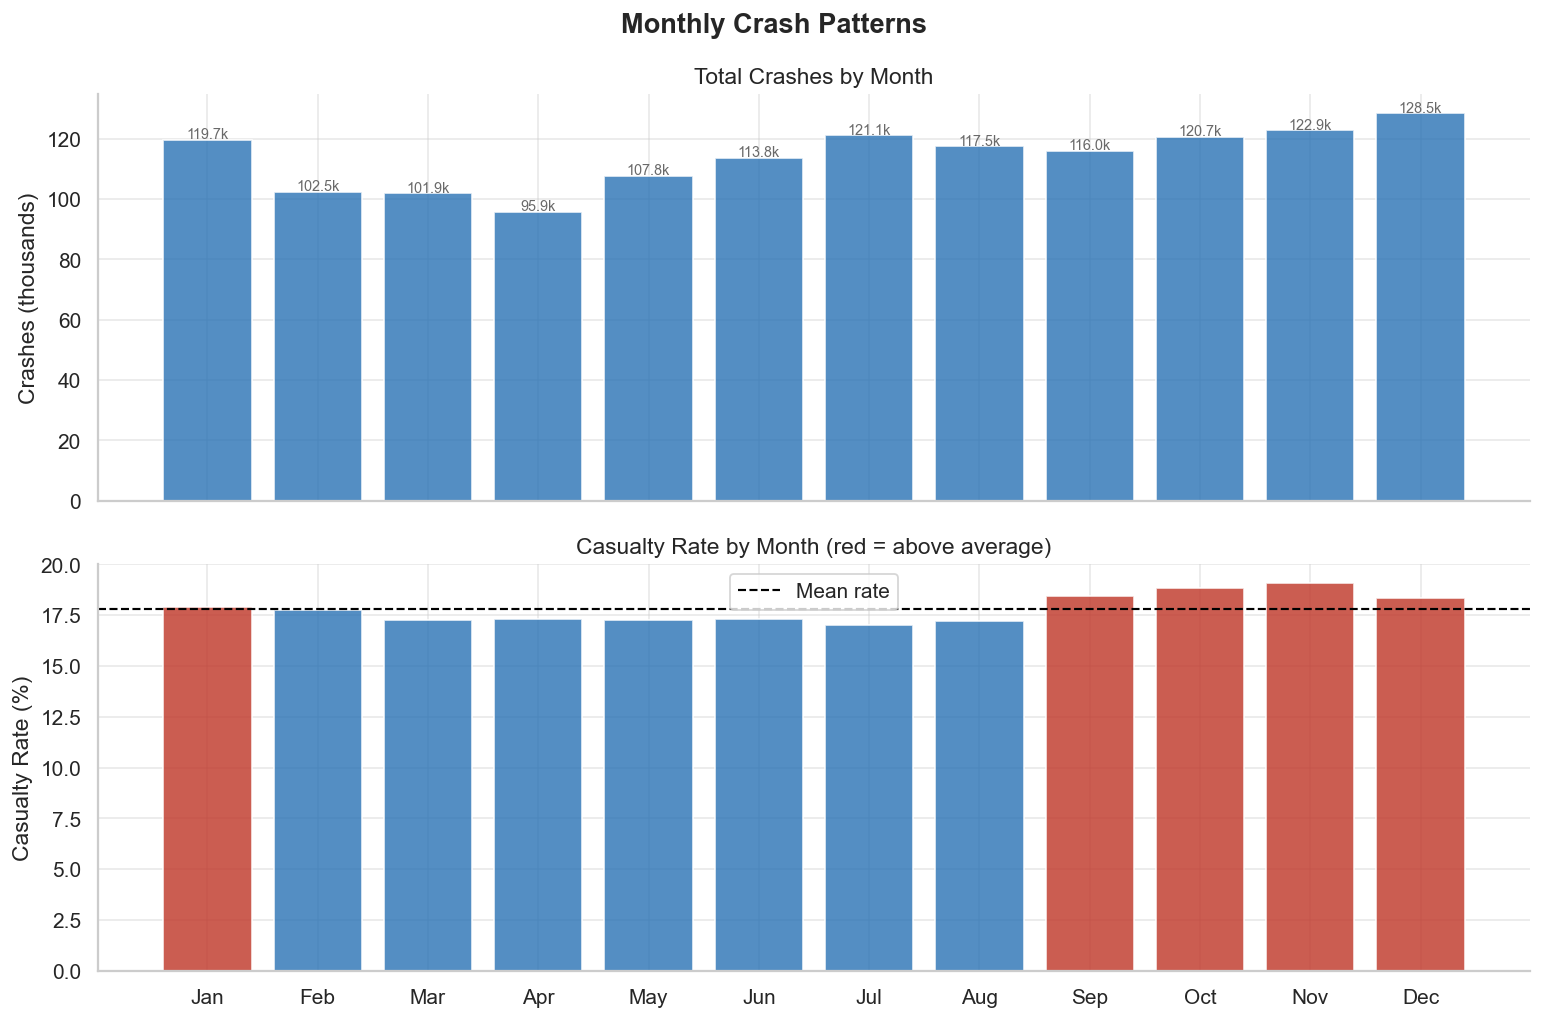

In [171]:
mon = (df.groupby("month")
       .agg(crashes=("is_casualty","count"), casualties=("is_casualty","sum"))
       .assign(casualty_rate=lambda x: x["casualties"]/x["crashes"]*100)
       .reset_index())
mon_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle("Monthly Crash Patterns", fontweight="bold")

ax1.bar(mon["month"], mon["crashes"]/1000, color=C_BLUE, alpha=0.82, zorder=2)
ax1.set_ylabel("Crashes (thousands)")
ax1.set_title("Total Crashes by Month")
for i, row in mon.iterrows():
    ax1.text(row["month"], row["crashes"]/1000+0.3, f"{row['crashes']/1000:.1f}k",
             ha="center", fontsize=8, color="dimgrey")

ax2.bar(mon["month"], mon["casualty_rate"],
        color=[C_RED if r > mon["casualty_rate"].mean() else C_BLUE for r in mon["casualty_rate"]],
        alpha=0.82, zorder=2)
ax2.axhline(mon["casualty_rate"].mean(), color="black", lw=1.2, linestyle="--", label="Mean rate")
ax2.set_ylabel("Casualty Rate (%)")
ax2.set_title("Casualty Rate by Month (red = above average)")
ax2.set_xticks(range(1,13)); ax2.set_xticklabels(mon_labels)
ax2.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq1_month.png", bbox_inches="tight")
plt.show()


#### Chart 1 — Total Crashes by Month:

Range is surprisingly narrow — 95.9k (April) to 128.5k (December)
No dramatic summer spike like you might expect — crashes are fairly evenly distributed year-round
December is highest — makes sense: holiday traffic, early darkness, wet/icy roads, more impaired driving
April is lowest — spring, longer daylight, mild weather, less holiday traffic

#### Chart 2 — Casualty Rate by Month:

The variation is very small — roughly 17% to 19% across all months
Sep, Oct, Nov, Dec are above average (red) — fall/winter months consistently more dangerous in terms of injury severity
Jan is also just above the mean despite being a high-volume month
Summer months (Jun, Jul, Aug) are actually below average for casualty rate despite high activity

**Note:** Summer (especially July, August) = more crashes but lower injury rate → mostly low-speed urban fender-benders (more traffic, more PDO)
Fall/Winter = fewer crashes but higher injury rate → worse road conditions mean crashes that do happen are more severe

**Result** Monthly crash volume is relatively stable year-round (±15%), with December peaking due to holiday and weather factors. However casualty severity follows a seasonal pattern — fall and winter months (Sep–Dec) consistently produce above-average injury rates, likely driven by reduced visibility, wet/icy surfaces, and higher-speed rural crashes in adverse conditions.

### 3.3 Season Analysis

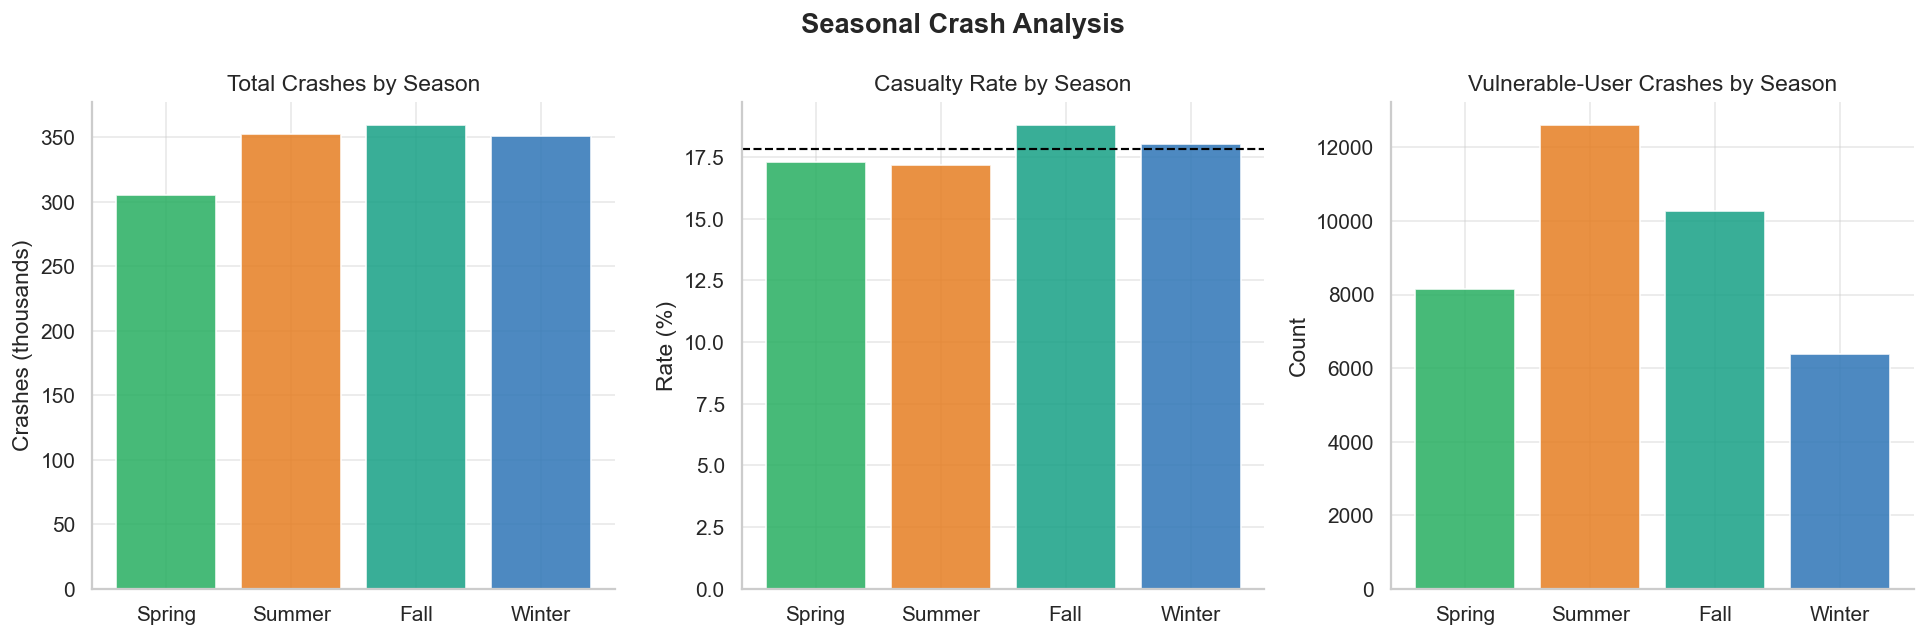

In [173]:
season_order = ["Spring","Summer","Fall","Winter"]
sea = (df.groupby("season")
       .agg(crashes=("is_casualty","count"), casualties=("is_casualty","sum"))
       .assign(casualty_rate=lambda x: x["casualties"]/x["crashes"]*100,
               vuln_crashes=lambda x: df[df["is_vulnerable"]==1].groupby("season").size())
       .reset_index())
sea["season"] = pd.Categorical(sea["season"], categories=season_order, ordered=True)
sea = sea.sort_values("season").reset_index(drop=True)

sea_pal = {"Spring": C_GREEN, "Summer": C_ORANGE, "Fall": C_TEAL, "Winter": C_BLUE}
colors = [sea_pal[s] for s in sea["season"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Seasonal Crash Analysis", fontweight="bold")

axes[0].bar(sea["season"], sea["crashes"]/1000, color=colors, alpha=0.85)
axes[0].set_title("Total Crashes by Season"); axes[0].set_ylabel("Crashes (thousands)")

axes[1].bar(sea["season"], sea["casualty_rate"], color=colors, alpha=0.85)
axes[1].axhline(sea["casualty_rate"].mean(), color="black", ls="--", lw=1.2)
axes[1].set_title("Casualty Rate by Season"); axes[1].set_ylabel("Rate (%)")

# Vulnerable crashes by season
vuln_sea = df[df["is_vulnerable"]==1].groupby("season").size().reindex(season_order)
axes[2].bar(season_order, vuln_sea.values, color=colors, alpha=0.85)
axes[2].set_title("Vulnerable-User Crashes by Season"); axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq1_season.png", bbox_inches="tight")
plt.show()


#### Chart 1 — Total Crashes by Season:

Remarkably even — Spring 305k, Summer 352k, Fall 358k, Winter 351k
Fall is highest. Spring is the only notably lower season (~15% below the others)
Takeaway: BC roads are similar year-round, not just in winter

#### Chart 2 — Casualty Rate by Season:

Again, small range — roughly 17.3% to 18.6%
Fall is clearly the worst — above the mean line, highest of all seasons
Summer is the safest — lowest casualty rate despite high crash volume
Winter is slightly above mean, Spring is just below
The Fall spike aligns with the Sep/Oct/Nov finding from the monthly chart — wet leaves, early darkness, end of summer driving habits

#### Chart 3 — Vulnerable-User Crashes by Season:

This one is the most interesting of the three
Summer dominates at \~12.5k — nearly double Winter (\~6.5k)
Spring 8k, Fall 10.5k follow logically
This makes complete sense: cyclists and pedestrians are far more active outdoors in summer — more exposure = more crashes

**The critical insight here:** Combined chart 2 and chart 3 together. Summer has the most vulnerable user crashes but the lowest casualty rate overall. This suggests summer vulnerable user crashes may be lower speed (urban cycling, walking). Fall/winter have fewer vulnerable user crashes but those that happen are more severe.

**Result:** Seasonal crash volume is nearly uniform across all seasons (\~305–358k), but vulnerable user exposure is highly seasonal — summer accounts for disproportionately more vulnerable user crashes (\~33% of annual total) due to increased pedestrian and cyclist activity. Fall produces the highest overall casualty rates, likely due to deteriorating road conditions combined with drivers not yet adjusted to winter driving.

### 3.4 Day of Week

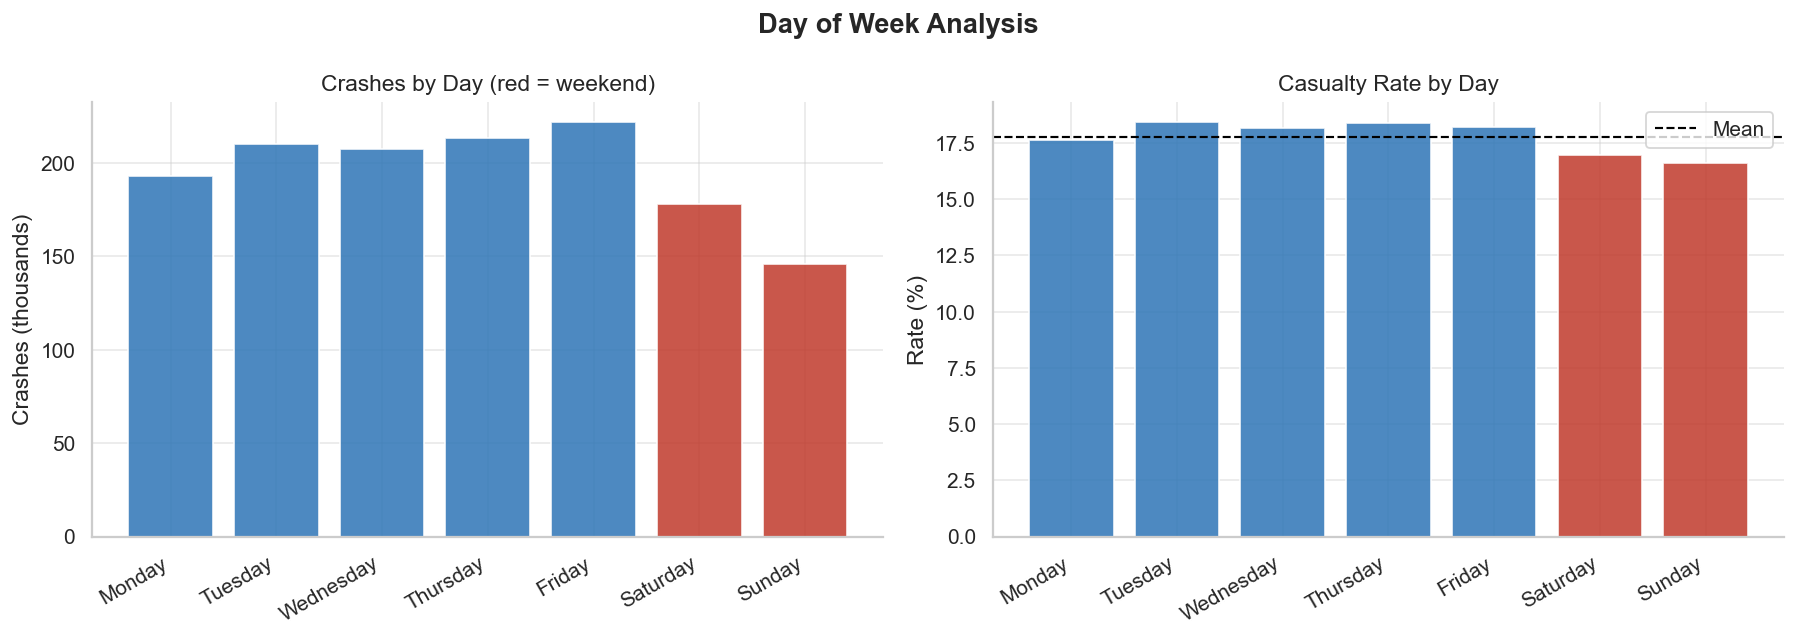

In [175]:
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["dow_clean"] = df["day_of_week"].str.title()
dow = (df[df["dow_clean"].isin(dow_order)]
       .groupby("dow_clean")
       .agg(crashes=("is_casualty","count"), casualties=("is_casualty","sum"))
       .assign(casualty_rate=lambda x: x["casualties"]/x["crashes"]*100)
       .reindex(dow_order).reset_index())

weekend_mask = dow["dow_clean"].isin(["Saturday","Sunday"])
colors_dow = [C_RED if w else C_BLUE for w in weekend_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Day of Week Analysis", fontweight="bold")

axes[0].bar(dow["dow_clean"], dow["crashes"]/1000, color=colors_dow, alpha=0.85)
axes[0].set_title("Crashes by Day (red = weekend)")
axes[0].set_ylabel("Crashes (thousands)")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha="right")

axes[1].bar(dow["dow_clean"], dow["casualty_rate"], color=colors_dow, alpha=0.85)
axes[1].axhline(dow["casualty_rate"].mean(), color="black", ls="--", lw=1.2, label="Mean")
axes[1].set_title("Casualty Rate by Day")
axes[1].set_ylabel("Rate (%)")
axes[1].legend()
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq1_dow.png", bbox_inches="tight")
plt.show()


#### Chart 1 — Crash Volume by Day:

Weekdays dominate — Friday is peak at ~220k, Monday is lowest weekday at ~193k
Weekends drop sharply — Saturday ~178k, Sunday ~147k
This is expected: commuter traffic drives volume

#### Chart 2 — Casualty Rate by Day:

This is the counterintuitive result — weekdays have HIGHER casualty rates than weekends
Mon–Thu all sit above the mean line (\~18%)
Saturday and Sunday are both below the mean (\~17% and \~16.5%)
Friday is right at the mean

**Why is this surprising?** The common assumption is weekends = impaired/reckless driving = more dangerous. But the data says the opposite for BC.
Possible explanations:

Weekday commuter routes are higher speed — highway and arterial road crashes during rush hour tend to be more severe than low-speed weekend urban driving
Weekend crashes skew toward parking lots, local roads — more PDO fender-benders at lower speeds
Impaired driving effect may be diluted — weekends have more crashes overall but also far more minor incidents that bring the rate down


**Result:** Weekday crashes are more frequent and more severe than weekend crashes — the opposite of conventional wisdom. Weekdays account for ~77% of all crashes but produce above-average casualty rates, suggesting commuter route conditions (higher speeds, congestion, fatigue) are a greater injury risk factor than weekend driving behaviour in BC.

### 3.5 Hour of Day (Collision Hour)

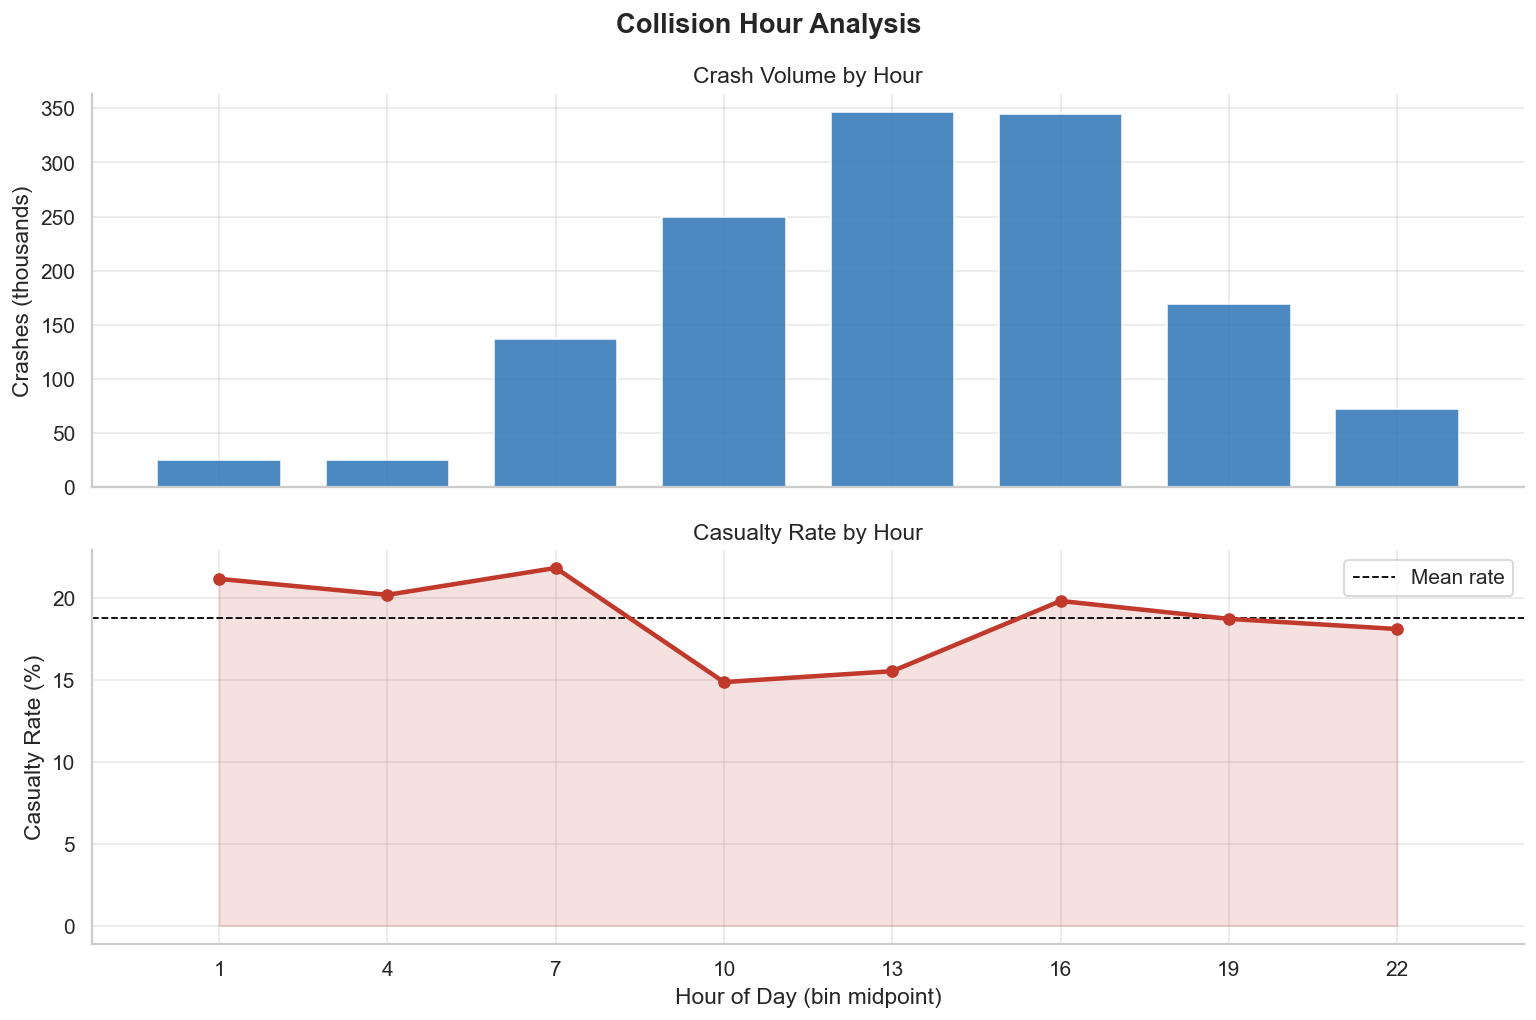

In [245]:
hr = (df.groupby("hour_approx")
      .agg(crashes=("is_casualty","count"), casualties=("is_casualty","sum"))
      .assign(casualty_rate=lambda x: x["casualties"]/x["crashes"]*100)
      .reset_index())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle("Collision Hour Analysis", fontweight="bold")

ax1.bar(hr["hour_approx"], hr["crashes"]/1000, color=C_BLUE, width=2.2, alpha=0.85, zorder=2)
ax1.set_ylabel("Crashes (thousands)")
ax1.set_title("Crash Volume by Hour")

ax2.plot(hr["hour_approx"], hr["casualty_rate"], color=C_RED, marker="o", lw=2.5, zorder=3)
ax2.fill_between(hr["hour_approx"], hr["casualty_rate"], alpha=0.15, color=C_RED)
ax2.axhline(hr["casualty_rate"].mean(), color="black", ls="--", lw=1, label="Mean rate")
ax2.set_ylabel("Casualty Rate (%)")
ax2.set_xlabel("Hour of Day (bin midpoint)")
ax2.set_title("Casualty Rate by Hour")
ax2.set_xticks(hr["hour_approx"])
ax2.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq1_hour.png", bbox_inches="tight")
plt.show()


#### Chart 1 — Crash Volume by Hour:

Classic double-peak rush hour pattern — 13:00 and 16:00 bins are the highest (~345k each)
Morning ramp-up starts at 07:00 (\~137k)
Late night (01:00, 04:00) very low — minimal traffic on roads
22:00 bin (\~72k) drops off sharply after evening

#### Chart 2 — Casualty Rate by Hour:

This is where it gets interesting — rate is inverse to volume
01:00 (\~22%) and 04:00 (\~21%) are the highest rates — above mean despite near-zero traffic
10:00 dips to \~15% — midday crashes are mostly low-speed PDO
16:00 is only \~20% despite being absolute peak volume
22:00 starts climbing back up

Rush hour produces the most casualties in absolute numbers, but late-night hours are proportionally the most dangerous — when a crash happens at 1–4am it is far more likely to injure someone (speed, impairment, reduced reaction time).

**Result:** Crash volume peaks at afternoon rush hour (13:00–16:00) accounting for the most absolute casualty crashes. However casualty rate peaks in the early hours (01:00–04:00 at ~21–22%), nearly 7 percentage points above the midday low of 15%. This separation between volume and severity risk is critical — high-volume hours are a systemic infrastructure problem, while late-night hours represent a behavioural risk (speeding, impairment) that produces disproportionate injury per crash.

### 3.6 Crash Frequency Heatmap — Hour × Day of Week

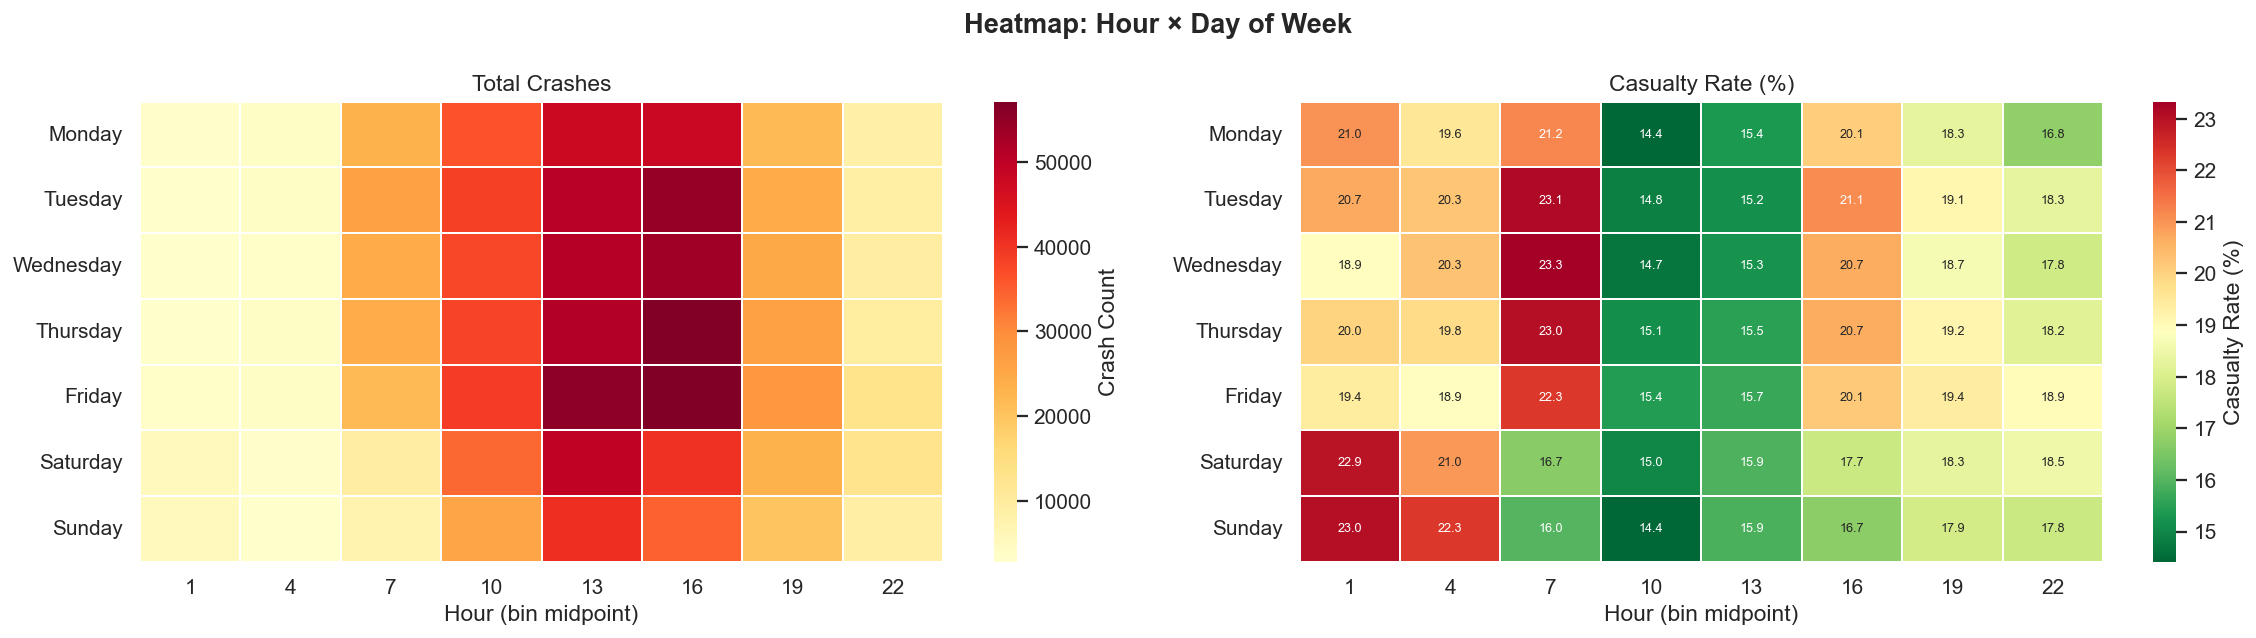

In [179]:
heat_df = (df[df["dow_clean"].isin(dow_order)]
           .groupby(["dow_clean","hour_approx"]).size()
           .reset_index(name="crashes")
           .pivot(index="dow_clean", columns="hour_approx", values="crashes")
           .reindex(dow_order))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("Heatmap: Hour × Day of Week", fontweight="bold")

sns.heatmap(heat_df, cmap="YlOrRd", ax=axes[0], linewidths=0.2,
            cbar_kws={"label":"Crash Count"})
axes[0].set_title("Total Crashes")
axes[0].set_xlabel("Hour (bin midpoint)")
axes[0].set_ylabel("")

# Casualty rate heatmap
heat_rate = (df[df["dow_clean"].isin(dow_order)]
             .groupby(["dow_clean","hour_approx"])["is_casualty"].mean().mul(100)
             .reset_index()
             .pivot(index="dow_clean", columns="hour_approx", values="is_casualty")
             .reindex(dow_order))
sns.heatmap(heat_rate, cmap="RdYlGn_r", ax=axes[1], linewidths=0.2,
            cbar_kws={"label":"Casualty Rate (%)"}, fmt=".1f", annot=True, annot_kws={"size":7})
axes[1].set_title("Casualty Rate (%)")
axes[1].set_xlabel("Hour (bin midpoint)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq1_heatmap.png", bbox_inches="tight")
plt.show()


#### Left heatmap — Crash Volume:

The dark red block at 13:00–16:00 across Mon–Fri is — weekday afternoon rush hour is the absolute peak
Weekends shift right — Saturday/Sunday peak later (13:00–16:00 still busy but the morning ramp-up is slower)
Late night (01:00, 04:00) is uniformly light yellow across all days — very low volume
07:00 weekdays shows a clear morning rush spike that disappears on weekends

#### Right heatmap — Casualty Rate:

Almost the exact inverse pattern of the left — the darkest red cells are Sunday 01:00 (23.0%) and Saturday 01:00 (22.9%)
**Weekend late night is the most dangerous combination** in the entire dataset — low volume but highest injury rate
Weekday 07:00 is also notably high (Tue 23.1%, Wed 23.3%, Thu 23.0%) — morning rush crashes are severe, likely higher speeds on commuter routes
10:00 across all days is consistently the greenest (safest rate ~14–15%) — midday low-speed urban driving
The worst single cell: Wednesday 07:00 at 23.3%

The key insight combining both: The cells with the highest volume (weekday 13:00–16:00) are orange/medium on the rate heatmap (~15–20%). The cells with the highest rate (weekend 01:00, weekday 07:00) have very low volume. This confirms two completely separate risk profiles:

High volume + moderate rate = afternoon rush hour (infrastructure/congestion problem)
Low volume + high rate = late night weekends and early morning weekdays (behavioural problem — impairment, speed)

**Result:** The hour × day heatmap reveals two distinct danger profiles. Weekday morning rush (07:00) produces the highest casualty rates among high-traffic periods (~23%), while weekend late night (Sat/Sun 01:00) tops the dataset at 23% with near-zero volume — strongly suggesting impairment. Policy interventions should target these two windows differently: infrastructure and signal timing for rush hour, enforcement for late-night weekends.

---
## 4.RQ1 Crash Configuration & Road Location


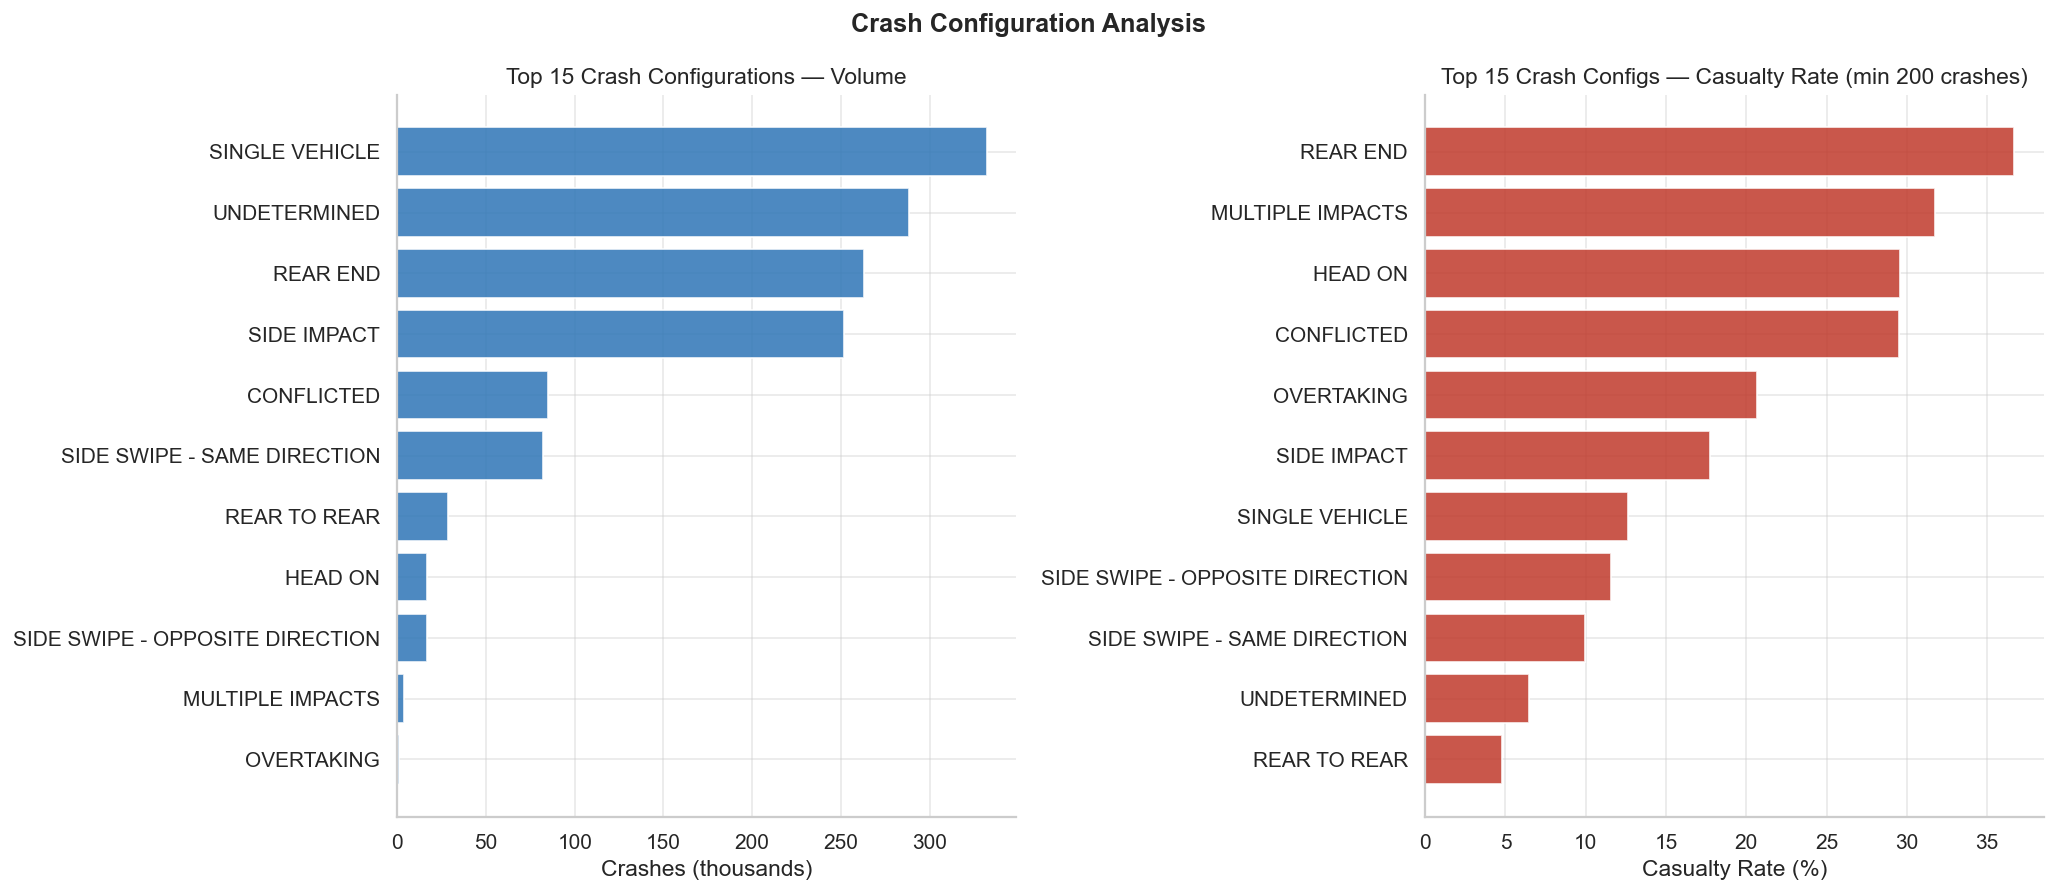

In [262]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Crash Configuration Analysis", fontweight="bold", fontsize=14)

cc = (df.groupby("crash_config")
      .agg(crashes=("is_casualty","count"), casualties=("is_casualty","sum"))
      .assign(casualty_rate=lambda x: x["casualties"]/x["crashes"]*100)
      .sort_values("crashes", ascending=True).tail(15))

axes[0].barh(cc.index, cc["crashes"]/1000, color=C_BLUE, alpha=0.85)
axes[0].set_xlabel("Crashes (thousands)")
axes[0].set_title("Top 15 Crash Configurations — Volume")

cc_rate = (df.groupby("crash_config")
           .agg(crashes=("is_casualty","count"), casualties=("is_casualty","sum"))
           .query("crashes >= 200")
           .assign(casualty_rate=lambda x: x["casualties"]/x["crashes"]*100)
           .sort_values("casualty_rate", ascending=True).tail(15))

axes[1].barh(cc_rate.index, cc_rate["casualty_rate"], color=C_RED, alpha=0.85)
axes[1].set_xlabel("Casualty Rate (%)")
axes[1].set_title("Top 15 Crash Configs — Casualty Rate (min 200 crashes)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq1_crash_config.png", bbox_inches="tight")
plt.show()

#### Left — Crash Config Volume:

Single Vehicle (\~320k) is the most common crash type by far — this includes hitting a curb, pole, barrier, skidding off road
Undetermined (\~260k) is concerning — over 1/4 million crashes with no configuration recorded (data quality caveat).

Rear End (\~210k) and Side Impact (\~200k) follow — typical urban traffic patterns

#### Right — Crash Config Casualty Rate:

Rear End at \~35% is the highest — surprising since rear ends are often considered minor, but high-speed highway rear ends are extremely dangerous
Multiple Impacts (\~32%) and Head On (\~30%) make intuitive sense — high energy collisions
Single Vehicle at \~16% is below average despite being the most common — most single vehicle crashes are low-speed (parking lot curb hits etc.)
Undetermined at \~10% lowest — likely minor unreported incidents

**Result**: Single vehicle crashes dominate volume (23%) but have below-average casualty rates — most are minor. Rear-end and head-on configurations have the highest injury rates (30–35%), pointing to speed as the primary severity driver. 

---
## 5. RQ1 — Intersection, Parking & Flag Analysis


Flag,Count,% of all crashes,Casualty rate (flag=1),Casualty rate (flag=0)
Pedestrian Involved,"14,873",1.1%,80.5%,17.2%
Cyclist Involved,"12,982",0.9%,65.4%,17.4%
Motorcycle Involved,"10,472",0.8%,55.0%,17.6%
Intersection,"563,396",41.2%,33.2%,7.1%
Heavy Vehicle Involved,"67,940",5.0%,15.1%,18.0%
Animal Involved,"59,288",4.3%,6.8%,18.3%
Parking Lot Crash,"432,086",31.6%,3.8%,24.3%
Parked Vehicle Involved,"444,359",32.5%,2.3%,25.3%


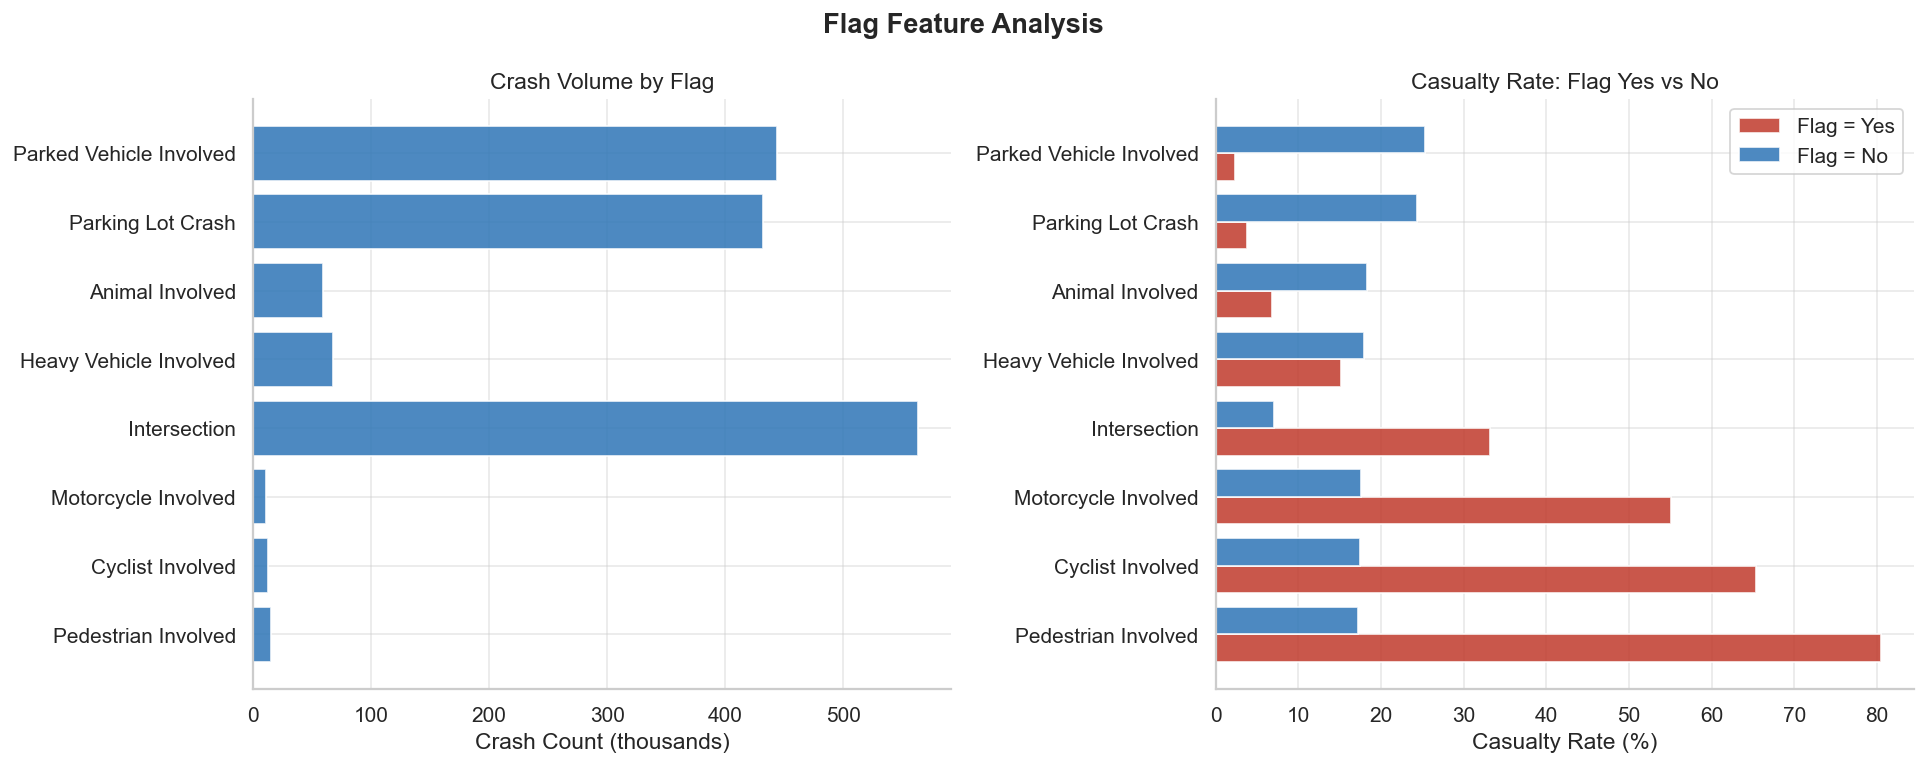

In [183]:
flag_cols = {
    "intersection":       "Intersection",
    "flag_cyclist":       "Cyclist Involved",
    "flag_pedestrian":    "Pedestrian Involved",
    "flag_motorcycle":    "Motorcycle Involved",
    "flag_heavy_veh":     "Heavy Vehicle Involved",
    "flag_animal":        "Animal Involved",
    "flag_parked_vehicle":"Parked Vehicle Involved",
    "flag_parking_lot":   "Parking Lot Crash",
}

records = []
for col, label in flag_cols.items():
    if col in df.columns:
        sub = df[df[col] == 1]
        sub_no = df[df[col] == 0]
        records.append({
            "Flag": label,
            "Count": len(sub),
            "% of all crashes": len(sub)/len(df)*100,
            "Casualty rate (flag=1)": sub["is_casualty"].mean()*100,
            "Casualty rate (flag=0)": sub_no["is_casualty"].mean()*100,
        })

flag_df = pd.DataFrame(records).sort_values("Casualty rate (flag=1)", ascending=False)
display(flag_df.style.hide(axis="index").format({
    "Count": "{:,.0f}",
    "% of all crashes": "{:.1f}%",
    "Casualty rate (flag=1)": "{:.1f}%",
    "Casualty rate (flag=0)": "{:.1f}%",
}))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Flag Feature Analysis", fontweight="bold")

axes[0].barh(flag_df["Flag"], flag_df["Count"]/1000, color=C_BLUE, alpha=0.85)
axes[0].set_xlabel("Crash Count (thousands)")
axes[0].set_title("Crash Volume by Flag")

x = np.arange(len(flag_df))
axes[1].barh(x-0.2, flag_df["Casualty rate (flag=1)"], 0.4, color=C_RED, alpha=0.85, label="Flag = Yes")
axes[1].barh(x+0.2, flag_df["Casualty rate (flag=0)"], 0.4, color=C_BLUE, alpha=0.85, label="Flag = No")
axes[1].set_yticks(x); axes[1].set_yticklabels(flag_df["Flag"])
axes[1].set_xlabel("Casualty Rate (%)")
axes[1].set_title("Casualty Rate: Flag Yes vs No")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq1_flags.png", bbox_inches="tight")
plt.show()


#### Left chart — Volume:

Parked Vehicle (444k), Parking Lot (432k), Intersection (563k) dominate — these are all low-speed scenarios
Vulnerable user flags (Pedestrian 14.9k, Cyclist 13k, Motorcycle 10.5k) are tiny slivers — looks rare but watch the right chart


#### Right chart — Casualty Rate (Flag Yes vs No):
The red vs blue gap is the key visual here.

**Key Findings — Flag Feature Analysis**

| Flag | Count | % of Crashes | Casualty Rate (Yes) | Casualty Rate (No) | Multiplier |
|------|-------|-------------|--------------------|--------------------|------------|
| Pedestrian Involved | 14,873 | 1.1% | 80.5% | 17.2% | **4.7×** |
| Cyclist Involved | 12,982 | 0.9% | 65.4% | 17.4% | **3.8×** |
| Motorcycle Involved | 10,472 | 0.8% | 55.0% | 17.6% | **3.1×** |
| Intersection | 563,396 | 41.2% | 33.2% | 7.1% | **4.7×** |
| Heavy Vehicle Involved | 67,940 | 5.0% | 15.1% | 18.0% | 0.8× |
| Animal Involved | 59,288 | 4.3% | 6.8% | 18.3% | 0.4× |
| Parking Lot Crash | 432,086 | 31.6% | 3.8% | 24.3% | 0.2× |
| Parked Vehicle Involved | 444,359 | 32.5% | 2.3% | 25.3% | 0.1× |

**Key takeaways:**
- Vulnerable user flags are the strongest injury predictors — pedestrian involvement alone raises casualty rate from 17% → 80.5%
- Intersection crashes affect 41% of all records but carry a 33% casualty rate (4.7× higher than non-intersection) — a critical infrastructure finding
- Parking lot and parked vehicle crashes (~64% of all records combined) almost never result in injury, acting as a large diluting factor on the overall casualty rate
- Heavy vehicle, animal, and parking-related flags are associated with *lower* casualty rates than average — these crashes tend to be low-speed or involve protected occupants

---
## 6. RQ3 — Vulnerability Gap (2020–2024)


### 6.1 Road User Type — Full Profile

road_user_type,crashes,casualties,casualty_rate,pct_of_total
Pedestrian,"14,873","11,966",80.5%,1.1%
Cyclist,"12,229","7,793",63.7%,0.9%
Motorcyclist,"10,311","5,634",54.6%,0.8%
Car Occupant,"1,264,164","209,395",16.6%,92.4%
Heavy Vehicle,"66,808","9,428",14.1%,4.9%


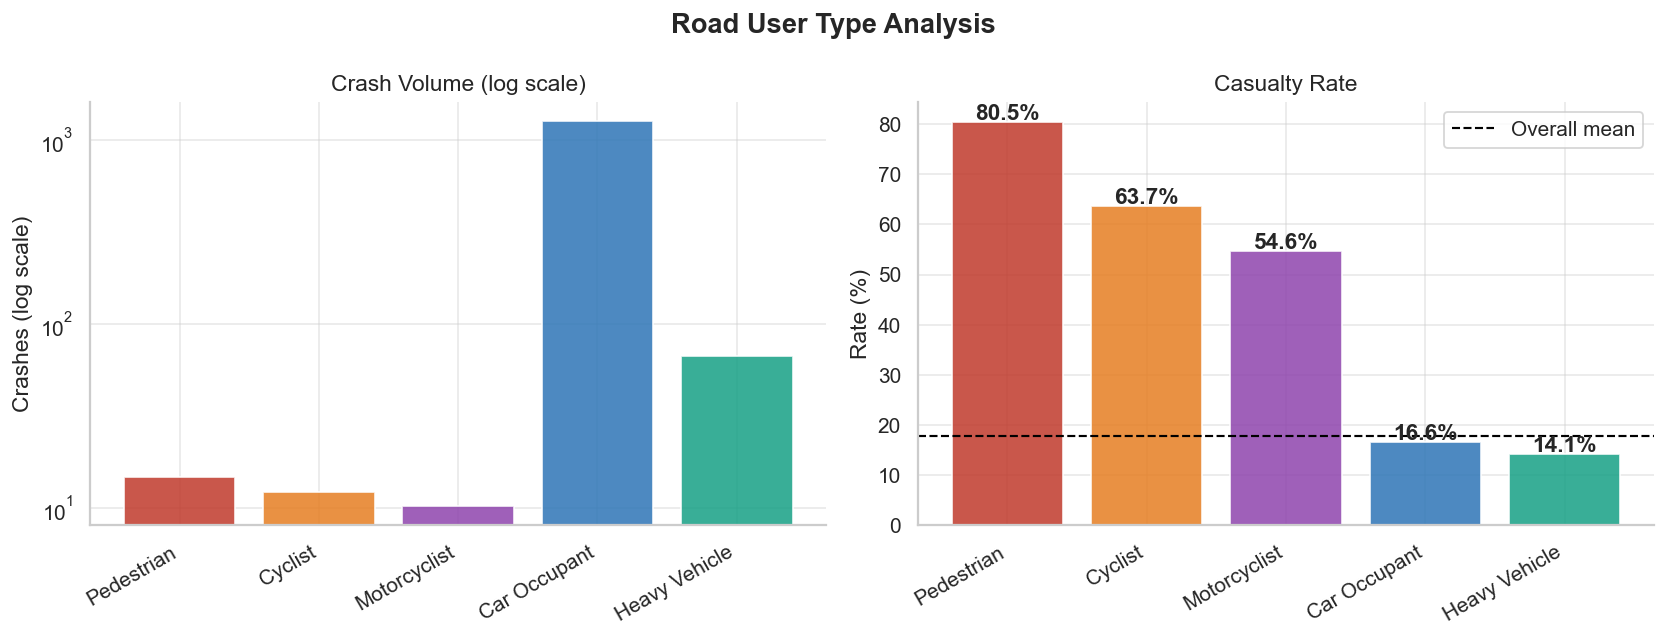

In [279]:
rut = (df.groupby("road_user_type")
       .agg(crashes=("is_casualty","count"), casualties=("is_casualty","sum"))
       .assign(casualty_rate=lambda x: x["casualties"]/x["crashes"]*100,
               pct_of_total=lambda x: x["crashes"]/len(df)*100)
       .sort_values("casualty_rate", ascending=False)
       .reset_index())

display(rut.style.hide(axis="index").format({
    "crashes": "{:,.0f}", "casualties": "{:,.0f}",
    "casualty_rate": "{:.1f}%", "pct_of_total": "{:.1f}%"
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Road User Type Analysis", fontweight="bold")

colors_rut = [VULN_PAL.get(r, C_GREY) for r in rut["road_user_type"]]

axes[0].bar(rut["road_user_type"], rut["crashes"]/1000, color=colors_rut, alpha=0.85)
axes[0].set_yscale("log")
axes[0].set_title("Crash Volume (log scale)")
axes[0].set_ylabel("Crashes (log scale)")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha="right")

bars2 = axes[1].bar(rut["road_user_type"], rut["casualty_rate"], color=colors_rut, alpha=0.85)
axes[1].axhline(df["is_casualty"].mean()*100, color="black", ls="--", lw=1.2, label="Overall mean")
axes[1].set_title("Casualty Rate")
axes[1].set_ylabel("Rate (%)")
axes[1].legend()
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")
for bar, val in zip(bars2, rut["casualty_rate"]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq3_road_user_type.png", bbox_inches="tight")
plt.show()


#### Findings:
Table above:

Pedestrian: 14,873 crashes → 11,966 casualties = 80.5% casualty rate

Cyclist: 12,229 → 7,793 = 63.7%

Motorcyclist: 10,311 → 5,634 = 54.6%

Car Occupant: 1,264,164 → 209,395 = 16.6% — 92.4% of all crashes

Heavy Vehicle: 66,808 → 9,428 = 14.1%

#### Chart (right): 
The dashed mean line at ~18% perfectly illustrates the divide — the three vulnerable user types tower above it, car occupant and heavy vehicle sit below.

### 6.2 Year-over-Year Casualty Rate by Road User Type

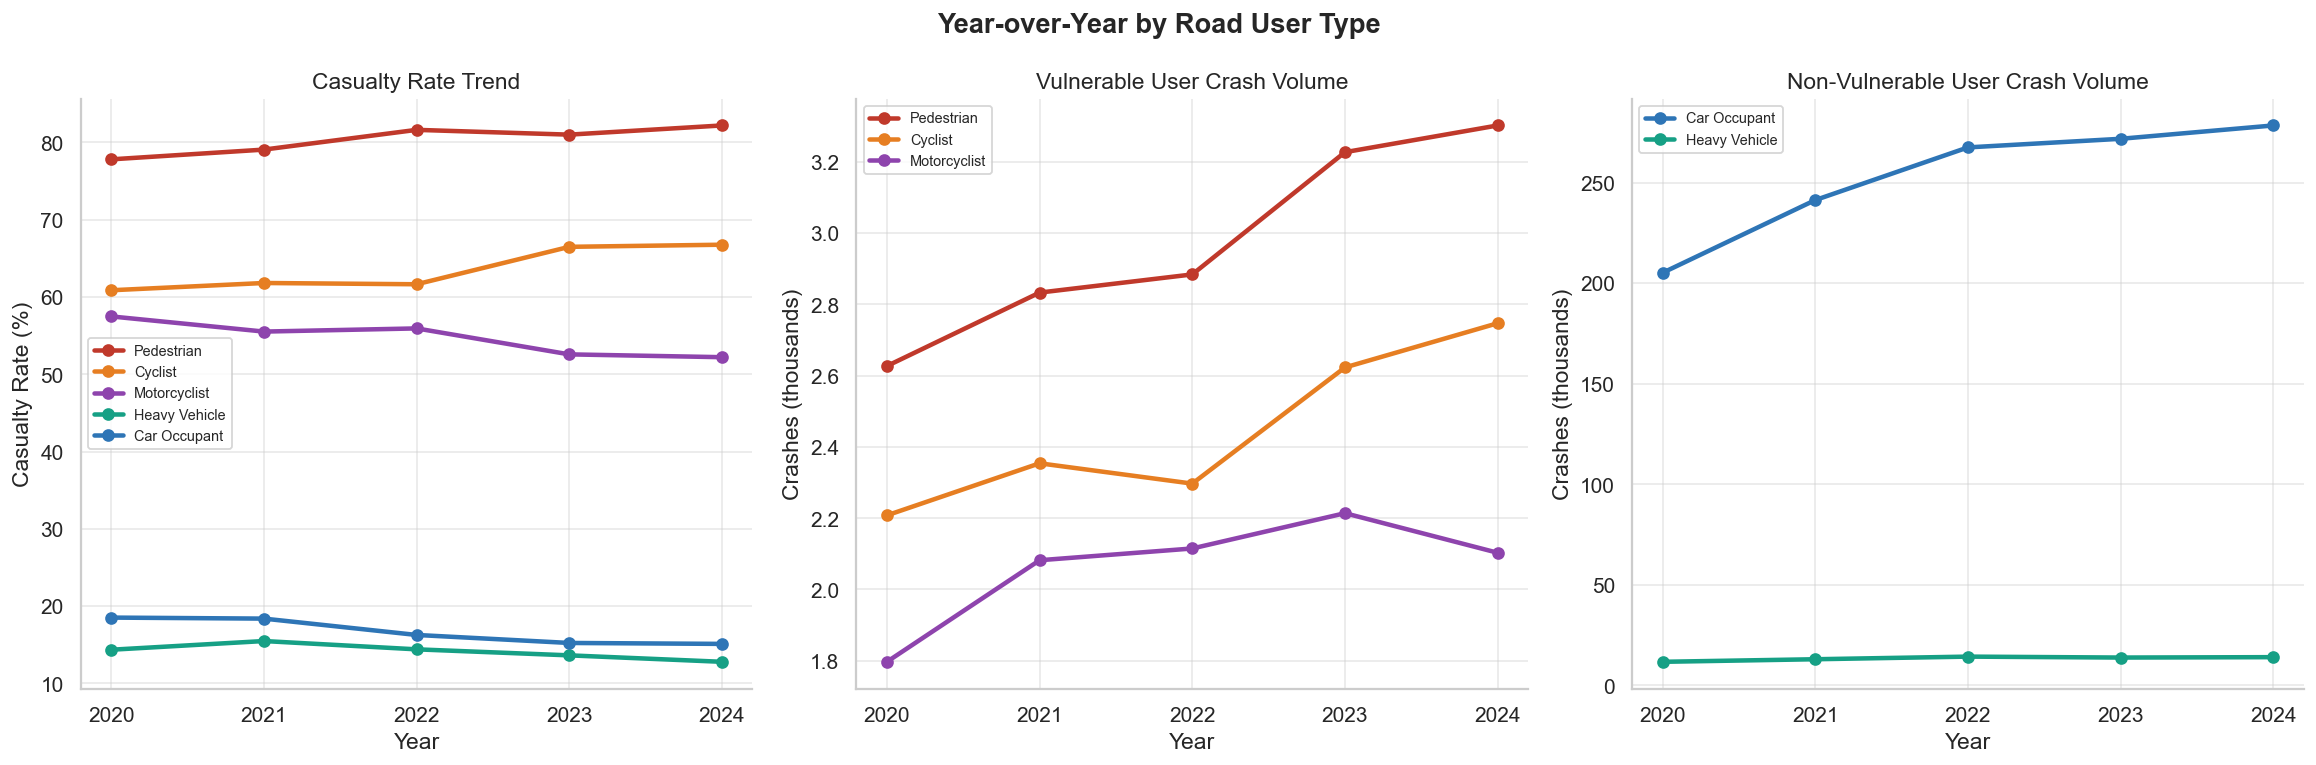

In [294]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Year-over-Year by Road User Type", fontweight="bold")

years_list = sorted(df["year"].dropna().unique().astype(int))

# Panel 1: Casualty rate — all groups
for rut in rut_order:
    sub = yoy[yoy["road_user_type"]==rut]
    axes[0].plot(sub["year"], sub["casualty_rate"], marker="o", lw=2.5,
                 label=rut, color=VULN_PAL.get(rut, C_GREY))
axes[0].set_title("Casualty Rate Trend")
axes[0].set_ylabel("Casualty Rate (%)")
axes[0].set_xlabel("Year")
axes[0].set_xticks(years_list)
axes[0].legend(fontsize=8)

# Panel 2: Vulnerable user volume only
for rut in ["Pedestrian", "Cyclist", "Motorcyclist"]:
    sub = yoy_vol[yoy_vol["road_user_type"]==rut]
    axes[1].plot(sub["year"], sub["count"]/1000, marker="o", lw=2.5,
                 label=rut, color=VULN_PAL.get(rut, C_GREY))
axes[1].set_title("Vulnerable User Crash Volume")
axes[1].set_ylabel("Crashes (thousands)")
axes[1].set_xlabel("Year")
axes[1].set_xticks(years_list)
axes[1].legend(fontsize=8)

# Panel 3: Non-vulnerable volume only
for rut in ["Car Occupant", "Heavy Vehicle"]:
    sub = yoy_vol[yoy_vol["road_user_type"]==rut]
    axes[2].plot(sub["year"], sub["count"]/1000, marker="o", lw=2.5,
                 label=rut, color=VULN_PAL.get(rut, C_GREY))
axes[2].set_title("Non-Vulnerable User Crash Volume")
axes[2].set_ylabel("Crashes (thousands)")
axes[2].set_xlabel("Year")
axes[2].set_xticks(years_list)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq3_yoy.png", bbox_inches="tight")
plt.show()


#### Left — Casualty Rate Trend (2020–2024):

Pedestrian: Starts at 78% → rises to 82% by 2024 — getting worse, not better

Cyclist: Relatively flat 61–62% until 2023, then jumps to 67% in 2024 — concerning upward spike

Motorcyclist: Gradual decline 58% → 52% — the one vulnerable group showing improvement

Car Occupant: Declining 19% → 15% — steady improvement

Heavy Vehicle: Declining 15% → 13% — also improving

The gap is widening. Car occupants are getting safer every year while pedestrians are getting more at risk. 

This is the core finding for RQ3.

#### Middle — Vulnerable User Crash Volume:

Pedestrian crashes growing sharply — 2.6k (2020) → 3.3k (2024), a ~27% increase

Cyclist also growing — 2.2k → 2.8k, ~27% increase as well

Motorcyclist — interesting pattern, low in 2020 (COVID, less riding), rose to 2.2k by 2023, then dropped slightly in 2024

All three groups trend upward overall — more vulnerable users on the road, likely reflecting post-COVID active transportation growth (cycling infrastructure expansion, more pedestrians in urban areas)


#### Right — Non-Vulnerable Volume:

Car Occupant steep growth 205k → 275k — population and vehicle growth in BC

Heavy Vehicle essentially flat — commercial traffic unchanged


Combining all three panels — the complete RQ3 picture:

Pedestrians are facing a compounding problem:

More pedestrian crashes (panel 2 ↑)

Higher casualty rate per crash (panel 1 ↑)

Meanwhile car occupants have more crashes but are getting safer (panel 1 ↓, panel 3 ↑)

This is structural inequality in the clearest possible form.

**Note:** All three vulnerable user groups saw crash volume growth of 20–30% from 2020–2024, likely reflecting increased active transportation post-COVID. Critically this volume growth coincided with rising casualty rates for pedestrians and cyclists — meaning the road network is not keeping pace with the shift toward active transportation. Car occupants in contrast absorbed a 34% crash volume increase while their casualty rate fell, underscoring that road safety improvements disproportionately benefit vehicle occupants.

### 6.3 Vulnerable vs Non-Vulnerable — Rate Gap Over Time

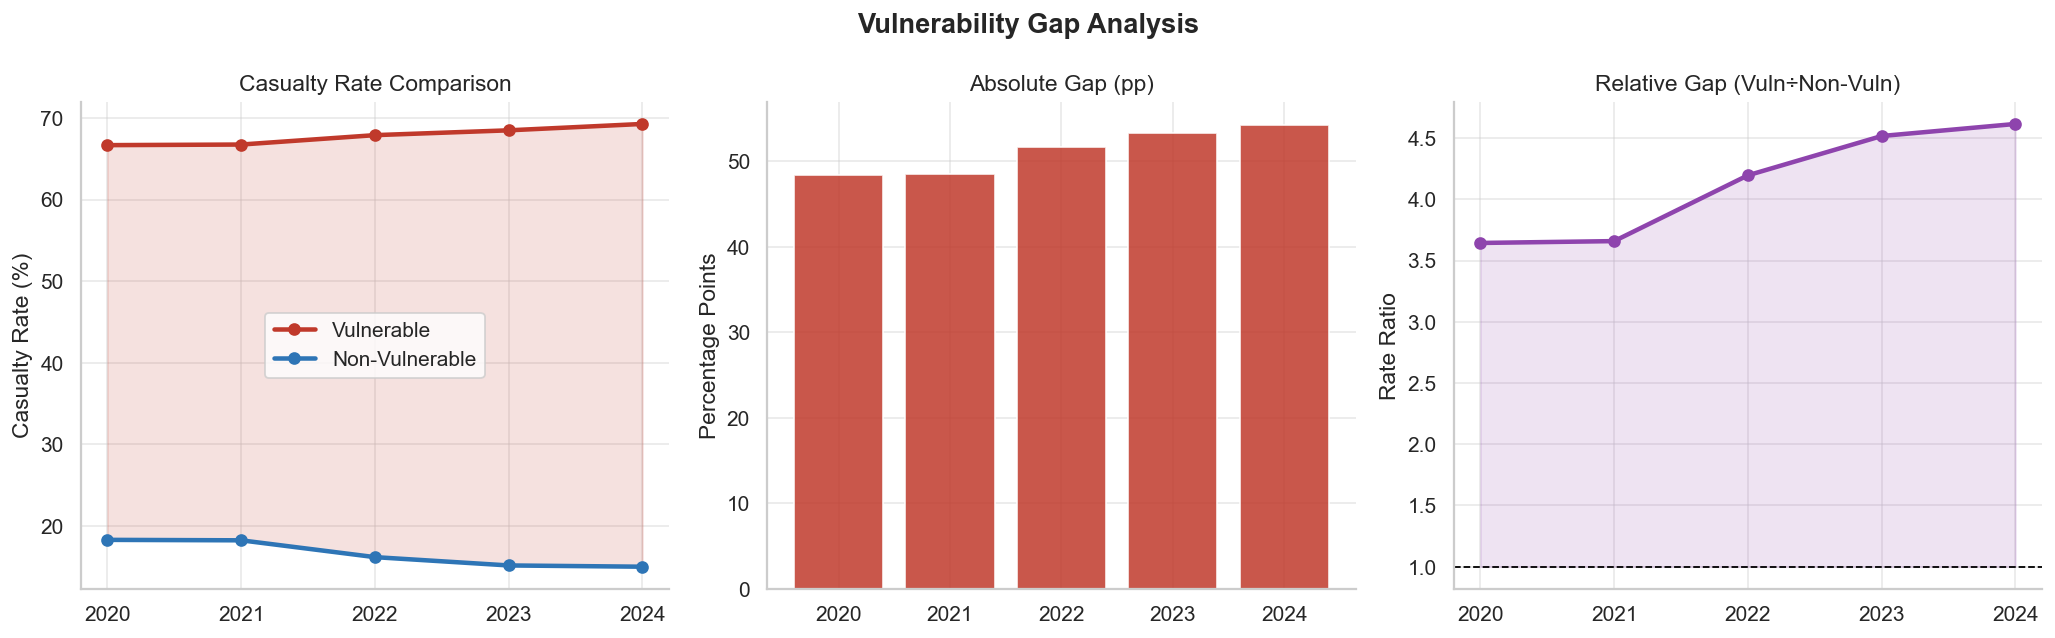

In [190]:
gap = (df.groupby(["year","is_vulnerable"])["is_casualty"]
       .agg(["sum","count"])
       .assign(rate=lambda x: x["sum"]/x["count"]*100)
       .reset_index())

vuln_r    = gap[gap["is_vulnerable"]==1].set_index("year")["rate"]
nonvuln_r = gap[gap["is_vulnerable"]==0].set_index("year")["rate"]
gap_abs   = vuln_r - nonvuln_r
years_list = sorted(df["year"].dropna().unique().astype(int))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Vulnerability Gap Analysis", fontweight="bold")

axes[0].plot(years_list, vuln_r.reindex(years_list),    marker="o", lw=2.5, color=C_RED,  label="Vulnerable")
axes[0].plot(years_list, nonvuln_r.reindex(years_list), marker="o", lw=2.5, color=C_BLUE, label="Non-Vulnerable")
axes[0].fill_between(years_list, nonvuln_r.reindex(years_list), vuln_r.reindex(years_list),
                     alpha=0.15, color=C_RED)
axes[0].set_title("Casualty Rate Comparison")
axes[0].set_ylabel("Casualty Rate (%)")
axes[0].set_xticks(years_list)
axes[0].legend()

colors_gap = [C_RED if g > 0 else C_GREEN for g in gap_abs.reindex(years_list)]
axes[1].bar(years_list, gap_abs.reindex(years_list), color=colors_gap, alpha=0.85)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Absolute Gap (pp)")
axes[1].set_ylabel("Percentage Points")
axes[1].set_xticks(years_list)

rel_gap = (vuln_r / nonvuln_r).reindex(years_list)
axes[2].plot(years_list, rel_gap, marker="o", lw=2.5, color=C_PURPLE)
axes[2].axhline(1, color="black", ls="--", lw=1)
axes[2].fill_between(years_list, 1, rel_gap, alpha=0.15, color=C_PURPLE)
axes[2].set_title("Relative Gap (Vuln÷Non-Vuln)")
axes[2].set_ylabel("Rate Ratio")
axes[2].set_xticks(years_list)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq3_gap.png", bbox_inches="tight")
plt.show()


#### Left — Casualty Rate Comparison:

Vulnerable: 67% → 70% — slowly but consistently rising

Non-Vulnerable: 19% → 16% — slowly but consistently falling

The two lines are moving in opposite directions — that red shaded gap is visually widening every year


#### Middle — Absolute Gap (percentage points):

2020: 49pp gap

2021: 49pp (stable)

2022: 51pp (starts widening)

2023: 53pp

2024: 54pp

A 5 percentage point increase in the gap over just 4 years


#### Right — Relative Gap (Rate Ratio):

2020: 3.6× — vulnerable users already 3.6× more likely to be injured

2022: 4.2× — sharp jump

2023: 4.5×

2024: 4.6× — nearly 5× more likely to be injured than a car occupant

The dashed line at 1.0 = equality. The gap to that line represents structural inequality.


**Results:** This is the definitive answer to RQ3. The vulnerability gap is widening on every measure. The absolute gap grew from 49pp to 54pp (2020–2024), while the relative gap grew from 3.6× to 4.6×. A vulnerable road user in BC in 2024 is 4.6× more likely to be injured in a crash than a car occupant — up from 3.6× just four years earlier. The simultaneous divergence of both trend lines confirms this is not a statistical artifact but a structural and accelerating inequality in BC road safety outcomes.

---
## 7. RQ3 — Relative Index of Inequality (RII)
RII = group casualty rate ÷ Car Occupant casualty rate. RII > 1 = higher risk than baseline.


**RII Table** — how many times more likely a casualty crash vs Car Occupant:

,Pedestrian,Cyclist,Motorcyclist,Heavy Vehicle
year,,,,
2020,4.20,3.29,3.10,0.78
2021,4.30,3.36,3.02,0.84
2022,5.02,3.79,3.44,0.89
2023,5.32,4.36,3.45,0.89
2024,5.44,4.42,3.45,0.85


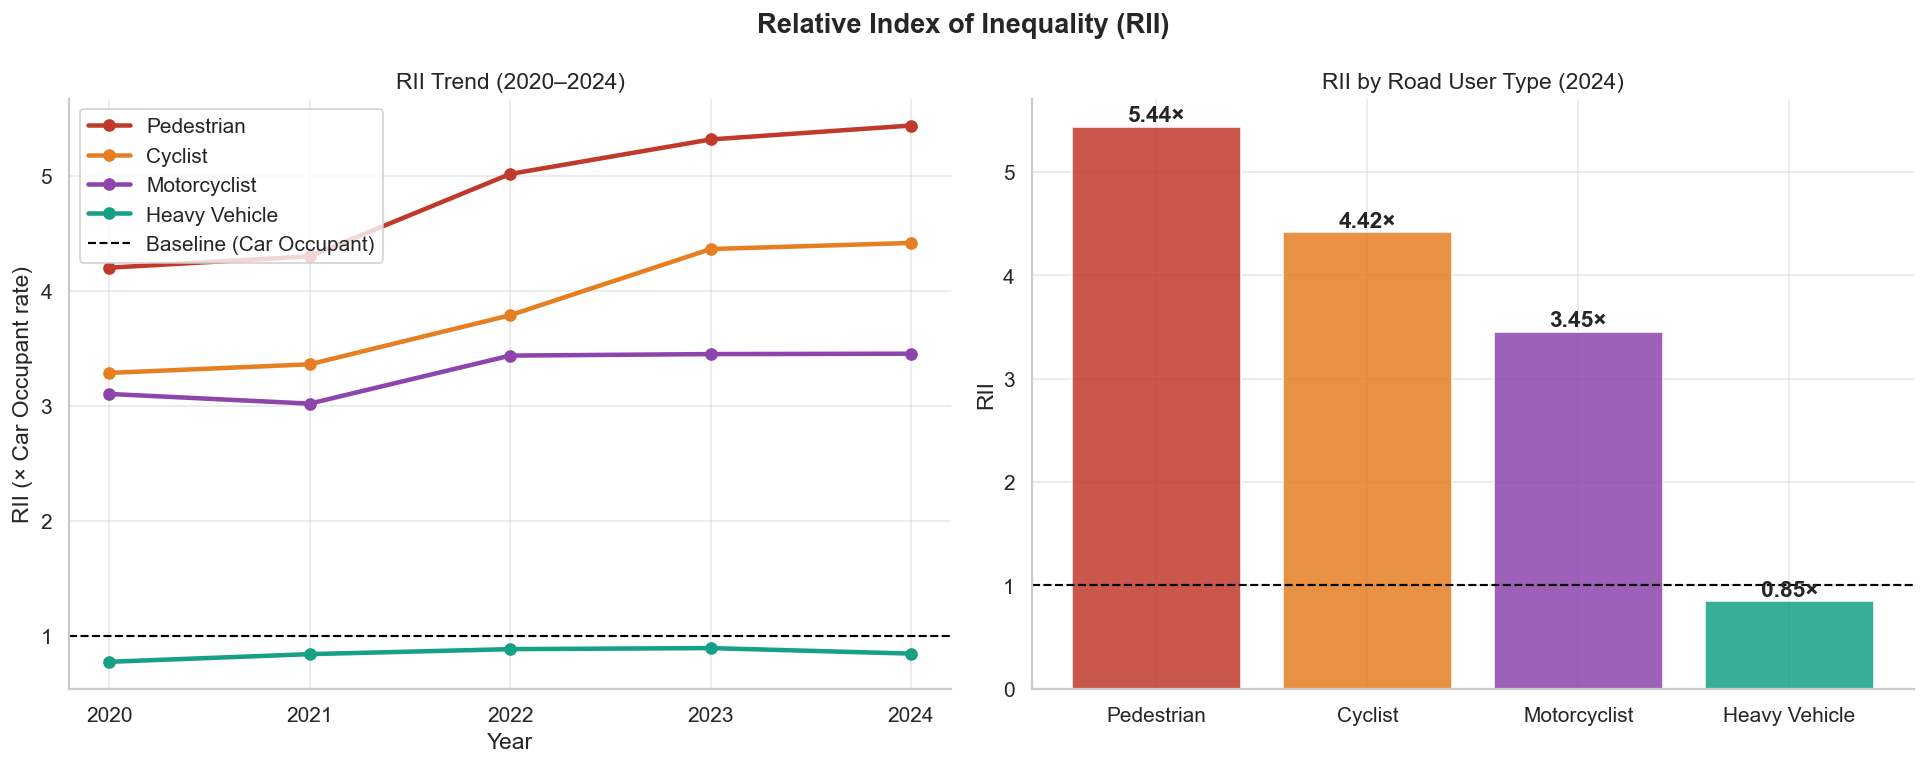

In [192]:
rii_raw = (df.groupby(["year","road_user_type"])["is_casualty"]
           .agg(["sum","count"])
           .assign(rate=lambda x: x["sum"]/x["count"]*100)
           .reset_index())

base = rii_raw[rii_raw["road_user_type"]=="Car Occupant"].set_index("year")["rate"]
rii_pivot = rii_raw.pivot(index="year", columns="road_user_type", values="rate")

vuln_ruts = [r for r in ["Pedestrian","Cyclist","Motorcyclist","Heavy Vehicle"] if r in rii_pivot.columns]
for rut in vuln_ruts:
    rii_pivot[f"RII_{rut}"] = rii_pivot[rut] / base

rii_cols = [f"RII_{r}" for r in vuln_ruts]

rii_display = rii_pivot[rii_cols].copy()
rii_display.columns = [c.replace("RII_","") for c in rii_display.columns]
display(Markdown("**RII Table** — how many times more likely a casualty crash vs Car Occupant:"))
display(rii_display.round(2))

rii_colors = {"Pedestrian": C_RED, "Cyclist": C_ORANGE,
              "Motorcyclist": C_PURPLE, "Heavy Vehicle": C_TEAL}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Relative Index of Inequality (RII)", fontweight="bold")

for rut in vuln_ruts:
    axes[0].plot(rii_pivot.index, rii_pivot[f"RII_{rut}"], marker="o", lw=2.5,
                 label=rut, color=rii_colors.get(rut, C_GREY))
axes[0].axhline(1, color="black", ls="--", lw=1.2, label="Baseline (Car Occupant)")
axes[0].set_title("RII Trend (2020–2024)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("RII (× Car Occupant rate)")
axes[0].set_xticks(sorted(rii_pivot.index.astype(int)))
axes[0].legend()

latest_year = int(sorted(rii_pivot.index)[-1])
latest_vals = {rut: rii_pivot.loc[latest_year, f"RII_{rut}"] for rut in vuln_ruts}
bars = axes[1].bar(list(latest_vals.keys()), list(latest_vals.values()),
                   color=[rii_colors.get(k, C_GREY) for k in latest_vals.keys()], alpha=0.85)
axes[1].axhline(1, color="black", ls="--", lw=1.2)
axes[1].set_title(f"RII by Road User Type ({latest_year})")
axes[1].set_ylabel("RII")
for bar, val in zip(bars, latest_vals.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f"{val:.2f}×", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq3_rii.png", bbox_inches="tight")
plt.show()


#### Table — RII values over time:

Pedestrian: 4.20 → 5.44 — the sharpest rise of any group, +1.24 in 4 years

Cyclist: 3.29 → 4.42 — also rising sharply, +1.13

Motorcyclist: 3.10 → 3.45 — modest increase, relatively stable

Heavy Vehicle: 0.78 → 0.85 — below 1.0 the entire time, meaning they are actually safer than car occupants


#### Left — RII Trend:

Pedestrian and Cyclist lines are climbing steeply — accelerating inequality

Motorcyclist relatively flat — not improving but not worsening dramatically

Heavy Vehicle flat below the dashed line — consistently the safest group

The gap between Pedestrian (5.44) and the baseline (1.0) has never been wider


#### Right — RII by Road User Type (2024):

Pedestrian 5.44× — in 2024 a pedestrian is 5.44 times more likely to be in a casualty crash than a car occupant

Cyclist 4.42×

Motorcyclist 3.45×

Heavy Vehicle 0.85× — actually safer than baseline, below the dashed line


**Results:** The RII quantifies the exact scale of inequality relative to the car occupant baseline. In 2024, pedestrians face a 5.44× higher casualty risk than car occupants — up from 4.20× in 2020, a 29% increase in relative inequality in just four years. Cyclists show a near-identical trajectory (3.29× → 4.42×, +34%). Heavy vehicles consistently fall below the baseline (RII < 1.0), confirming that vehicle protection is the dominant determinant of crash outcome in BC. The accelerating slope of both pedestrian and cyclist RII lines from 2022 onward is particularly concerning and warrants urgent policy attention.

---
## 8. RQ4 — Geographic / Municipal Analysis


### 8.1 Top 20 Municipalities — Crash Volume, Casualty Rate, Vulnerable Rate

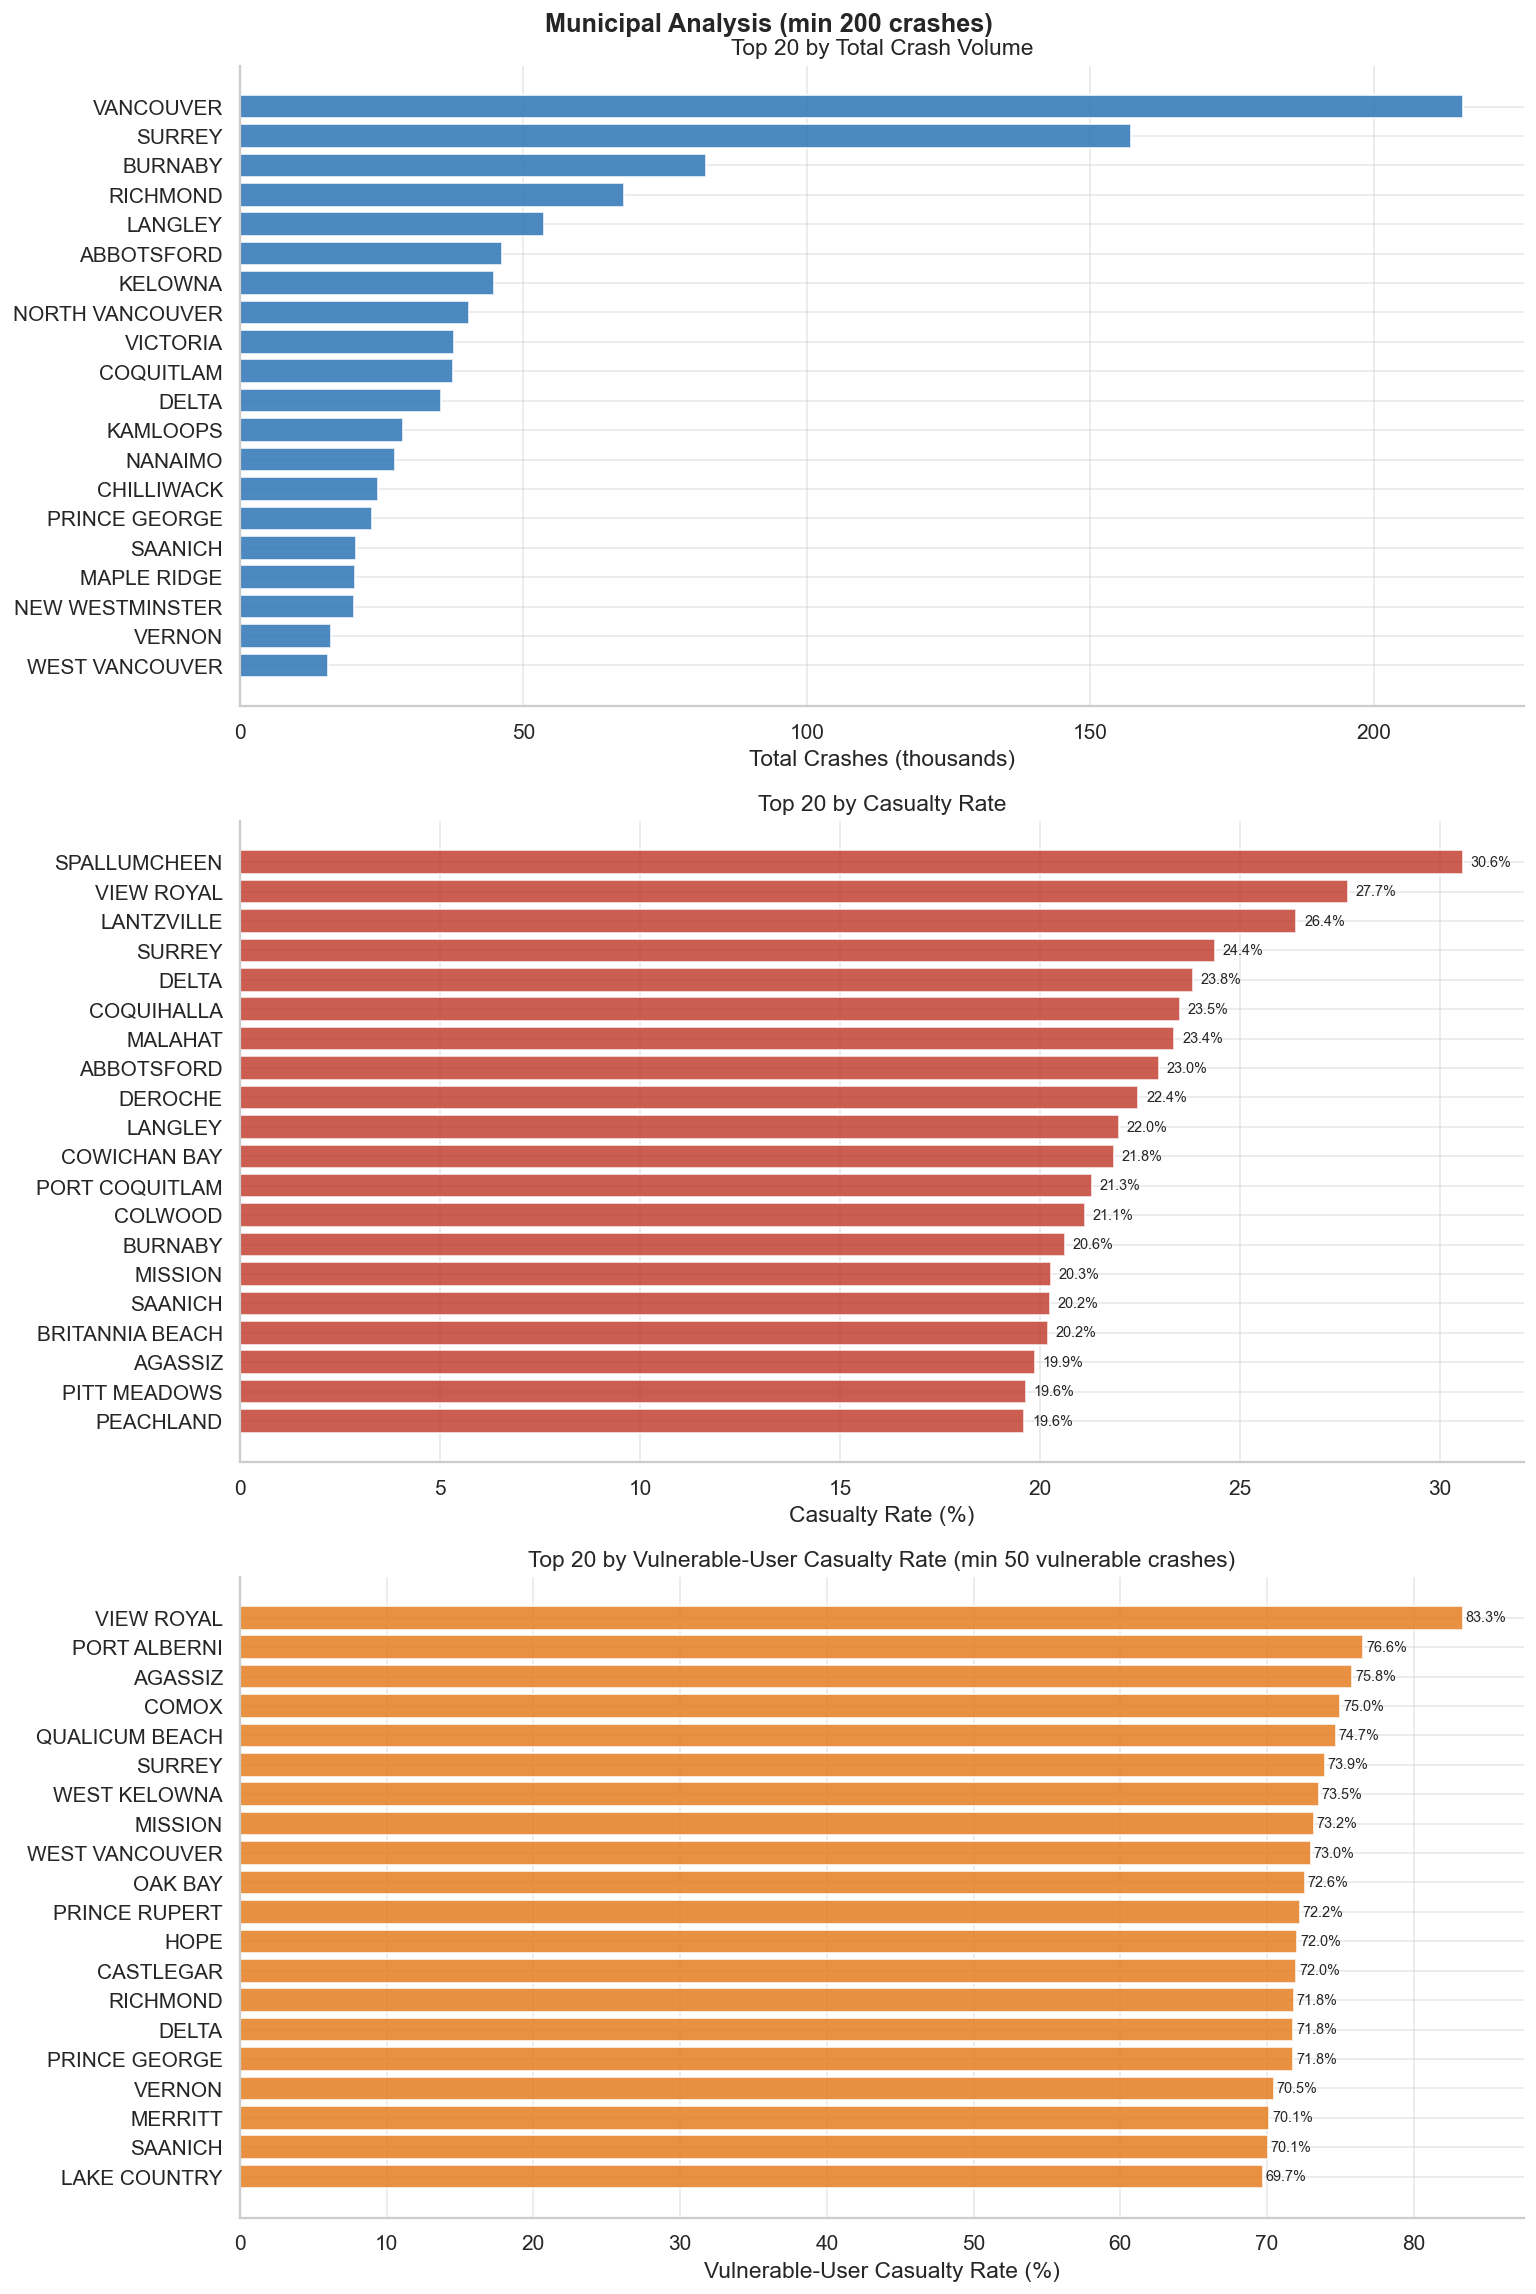

In [195]:
MIN_CRASHES = 200

muni = (df.groupby("municipality")
        .agg(
            total_crashes   = ("is_casualty","count"),
            casualties      = ("is_casualty","sum"),
            vuln_crashes    = ("is_vulnerable","sum"),
        )
        .assign(
            casualty_rate     = lambda x: x["casualties"]/x["total_crashes"]*100,
            vuln_pct          = lambda x: x["vuln_crashes"]/x["total_crashes"]*100,
        )
        .query(f"total_crashes >= {MIN_CRASHES}")
        .reset_index())

muni_vuln = (df[df["is_vulnerable"]==1]
             .groupby("municipality")
             .agg(vuln_total=("is_casualty","count"), vuln_cas=("is_casualty","sum"))
             .assign(vuln_casualty_rate=lambda x: x["vuln_cas"]/x["vuln_total"]*100)
             .query("vuln_total >= 50")
             .reset_index())

fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle(f"Municipal Analysis (min {MIN_CRASHES} crashes)", fontweight="bold", fontsize=14)

top_vol = muni.nlargest(20, "total_crashes")
axes[0].barh(top_vol["municipality"], top_vol["total_crashes"]/1000, color=C_BLUE, alpha=0.85)
axes[0].set_xlabel("Total Crashes (thousands)")
axes[0].set_title("Top 20 by Total Crash Volume")
axes[0].invert_yaxis()

top_rate = muni.nlargest(20, "casualty_rate")
bars = axes[1].barh(top_rate["municipality"], top_rate["casualty_rate"], color=C_RED, alpha=0.82)
axes[1].set_xlabel("Casualty Rate (%)")
axes[1].set_title("Top 20 by Casualty Rate")
axes[1].invert_yaxis()
for bar, val in zip(bars, top_rate["casualty_rate"]):
    axes[1].text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=8)

top_vuln = muni_vuln.nlargest(20, "vuln_casualty_rate")
bars2 = axes[2].barh(top_vuln["municipality"], top_vuln["vuln_casualty_rate"], color=C_ORANGE, alpha=0.85)
axes[2].set_xlabel("Vulnerable-User Casualty Rate (%)")
axes[2].set_title("Top 20 by Vulnerable-User Casualty Rate (min 50 vulnerable crashes)")
axes[2].invert_yaxis()
for bar, val in zip(bars2, top_vuln["vuln_casualty_rate"]):
    axes[2].text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq4_municipal.png", bbox_inches="tight")
plt.show()


#### Chart 1 — Top 20 by Total Crash Volume:

Vancouver (220k), Surrey (158k), Burnaby (83k) — Metro Vancouver dominates completely

Top 5 are all Metro Vancouver municipalities

Kelowna, Victoria, Kamloops, Nanaimo represent the interior and island

Expected pattern — volume follows population density


#### Chart 2 — Top 20 by Casualty Rate:

Completely different list from Chart 1 — this is the key insight here

Spallumcheen (30.6%), View Royal (27.7%), Lantzville (26.4%) — small municipalities topping the list

Surrey (24.4%) and Delta (23.8%) are the only high-volume municipalities appearing here

Coquihalla (23.5%) and Malahat (23.4%) — these are highways, not municipalities. High-speed rural corridors with severe crashes

Vancouver doesn't appear at all — large urban centres have lower casualty rates due to low-speed urban driving

The rate vs volume divergence is the core geographic finding for RQ4 — where crashes happen most is not where they are most dangerous.

#### Chart 3 — Top 20 by Vulnerable-User Casualty Rate:

View Royal (83.3%) — when a vulnerable user crashes here, 83% of the time it results in injury

Range is extremely compressed — all 20 municipalities are between 69.7% and 83.3%

Surrey (73.9%) appears here despite being #2 by volume — high vulnerable user risk AND high volume = double concern

Mix of small municipalities (Agassiz, Comox, Qualicum Beach) and large ones (Surrey, Richmond, Delta, Prince George)

Notable: West Vancouver (73.0%) and Oak Bay (72.6%) — affluent municipalities with high vulnerable user risk, potentially related to older pedestrian populations


**Results:** Municipal analysis reveals two distinct risk profiles. Urban centres (Vancouver, Surrey, Burnaby) dominate crash volume but mid-size and rural municipalities (Spallumcheen, Lantzville, Coquihalla) have the highest casualty rates — driven by higher road speeds and less forgiving infrastructure. For vulnerable users specifically, View Royal leads at 83.3% casualty rate, with Surrey being the most concerning municipality overall — appearing in both the high-volume and high vulnerable-user-rate lists simultaneously. Policy interventions should prioritize Surrey for vulnerable user protection given its combination of scale and severity.

### 8.2 Road User Composition — Top 10 Municipalities by Vulnerable Casualty Count

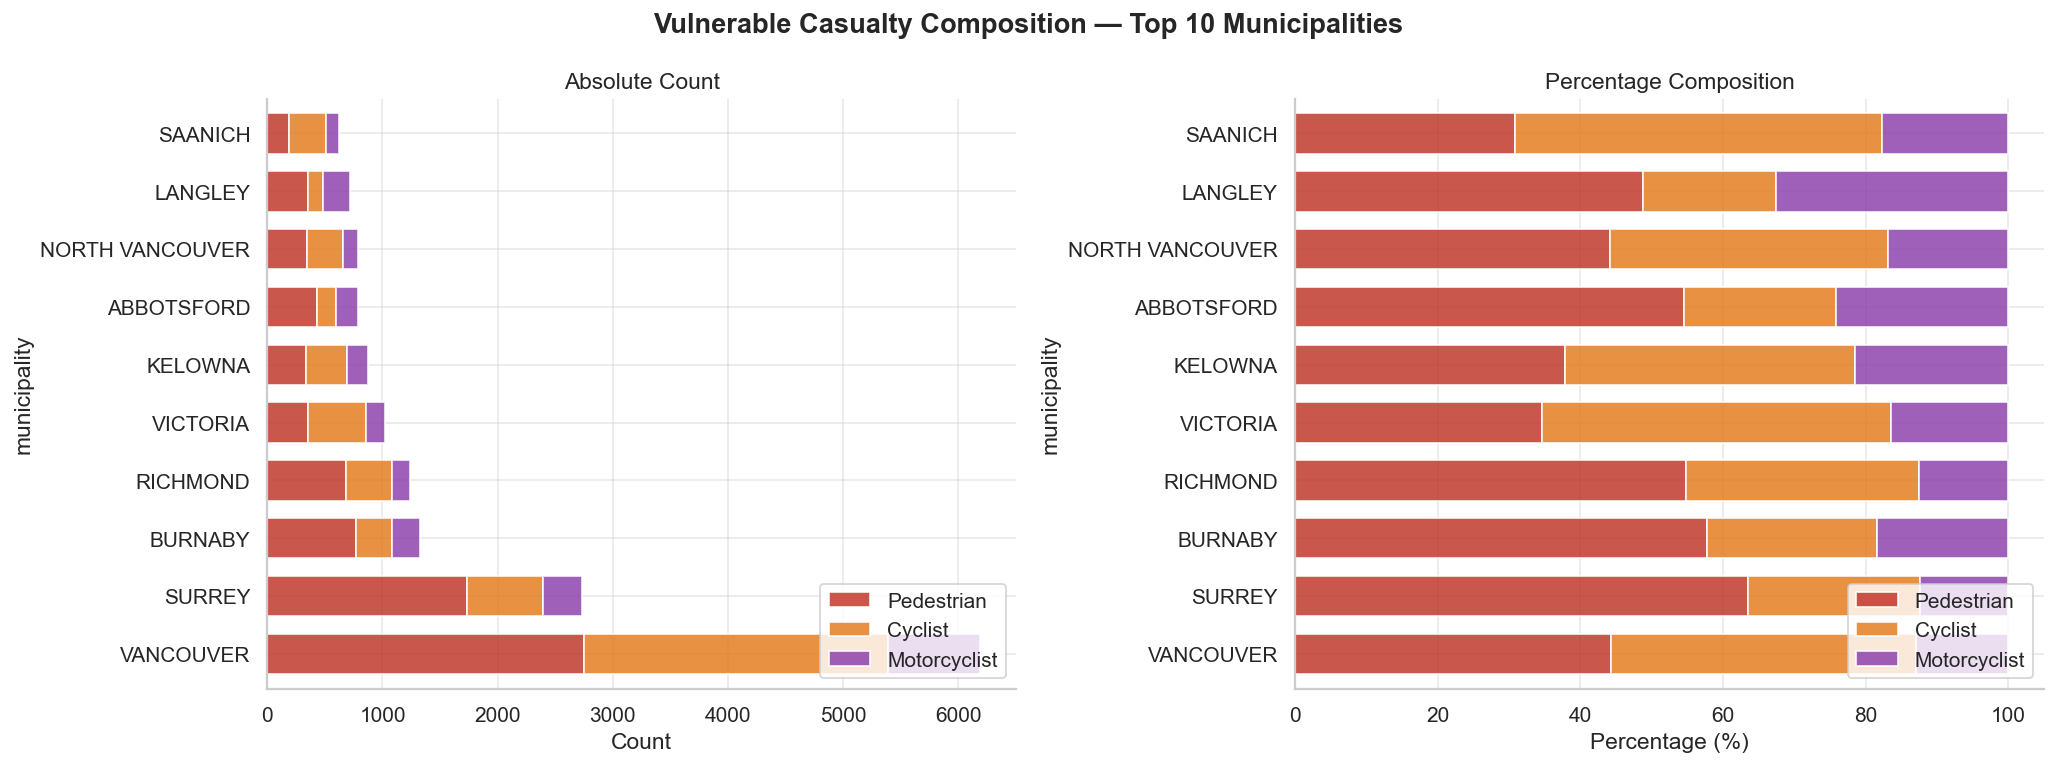

In [197]:
top10 = (df[(df["is_vulnerable"]==1) & (df["is_casualty"]==1)]
         .groupby("municipality").size()
         .nlargest(10).index.tolist())

breakdown = (df[df["municipality"].isin(top10) & (df["is_casualty"]==1) & (df["is_vulnerable"]==1)]
             .groupby(["municipality","road_user_type"]).size()
             .reset_index(name="count")
             .pivot(index="municipality", columns="road_user_type", values="count")
             .fillna(0).reindex(top10))

vuln_types = [c for c in ["Pedestrian","Cyclist","Motorcyclist"] if c in breakdown.columns]
breakdown_pct = breakdown[vuln_types].div(breakdown[vuln_types].sum(axis=1), axis=0)*100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Vulnerable Casualty Composition — Top 10 Municipalities", fontweight="bold")

breakdown[vuln_types].plot(kind="barh", stacked=True, ax=axes[0],
    color={"Pedestrian": C_RED, "Cyclist": C_ORANGE, "Motorcyclist": C_PURPLE},
    alpha=0.85, width=0.7)
axes[0].set_title("Absolute Count")
axes[0].set_xlabel("Count")
axes[0].legend(loc="lower right")

breakdown_pct.plot(kind="barh", stacked=True, ax=axes[1],
    color={"Pedestrian": C_RED, "Cyclist": C_ORANGE, "Motorcyclist": C_PURPLE},
    alpha=0.85, width=0.7)
axes[1].set_title("Percentage Composition")
axes[1].set_xlabel("Percentage (%)")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq4_top10_breakdown.png", bbox_inches="tight")
plt.show()


#### Left — Absolute Count:

Vancouver dominates massively — ~6,500 total vulnerable casualties, with cyclists being the largest single component (the big orange block)

Surrey is second at ~2,700 — pedestrians dominant here (large red block)

Rest of the top 10 are all under 1,500 — big drop-off after Vancouver and Surrey

Vancouver's cyclist count is striking — likely the largest cycling city in BC with the most infrastructure but also the most exposure


#### Right — Percentage Composition:

Vancouver: ~45% Cyclist, ~40% Pedestrian, ~15% Motorcyclist — uniquely cyclist-heavy, reflects Vancouver's cycling culture and infrastructure

Surrey: ~60% Pedestrian, ~25% Cyclist, ~15% Motorcyclist — pedestrian-dominant, reflects Surrey's arterial road network with high-speed multi-lane roads that are dangerous for pedestrians

Saanich, North Vancouver, Kelowna, Victoria: heavily cyclist-weighted — active transportation cities

Langley, Abbotsford: more balanced — mix of pedestrian and cyclist risk

Motorcyclist (purple) is relatively consistent across all municipalities at ~15-20%


The key contrast to note:

Vancouver's problem is cyclists. Surrey's problem is pedestrians. Same vulnerable user category, completely different composition — meaning the policy response should be different for each city.

**Results:** Vulnerable casualty composition varies significantly by municipality. Vancouver leads in absolute count (\~6,500) driven primarily by cyclist casualties — reflecting high cycling activity but also high exposure. Surrey's vulnerable casualties are pedestrian-dominant (~60%), consistent with its wide arterial road network designed for vehicle throughput rather than pedestrian safety. This composition analysis reveals that a single province-wide policy cannot address municipal-level vulnerability — Vancouver needs cycling infrastructure investment while Surrey needs pedestrian crossing improvements and speed reduction on arterials.

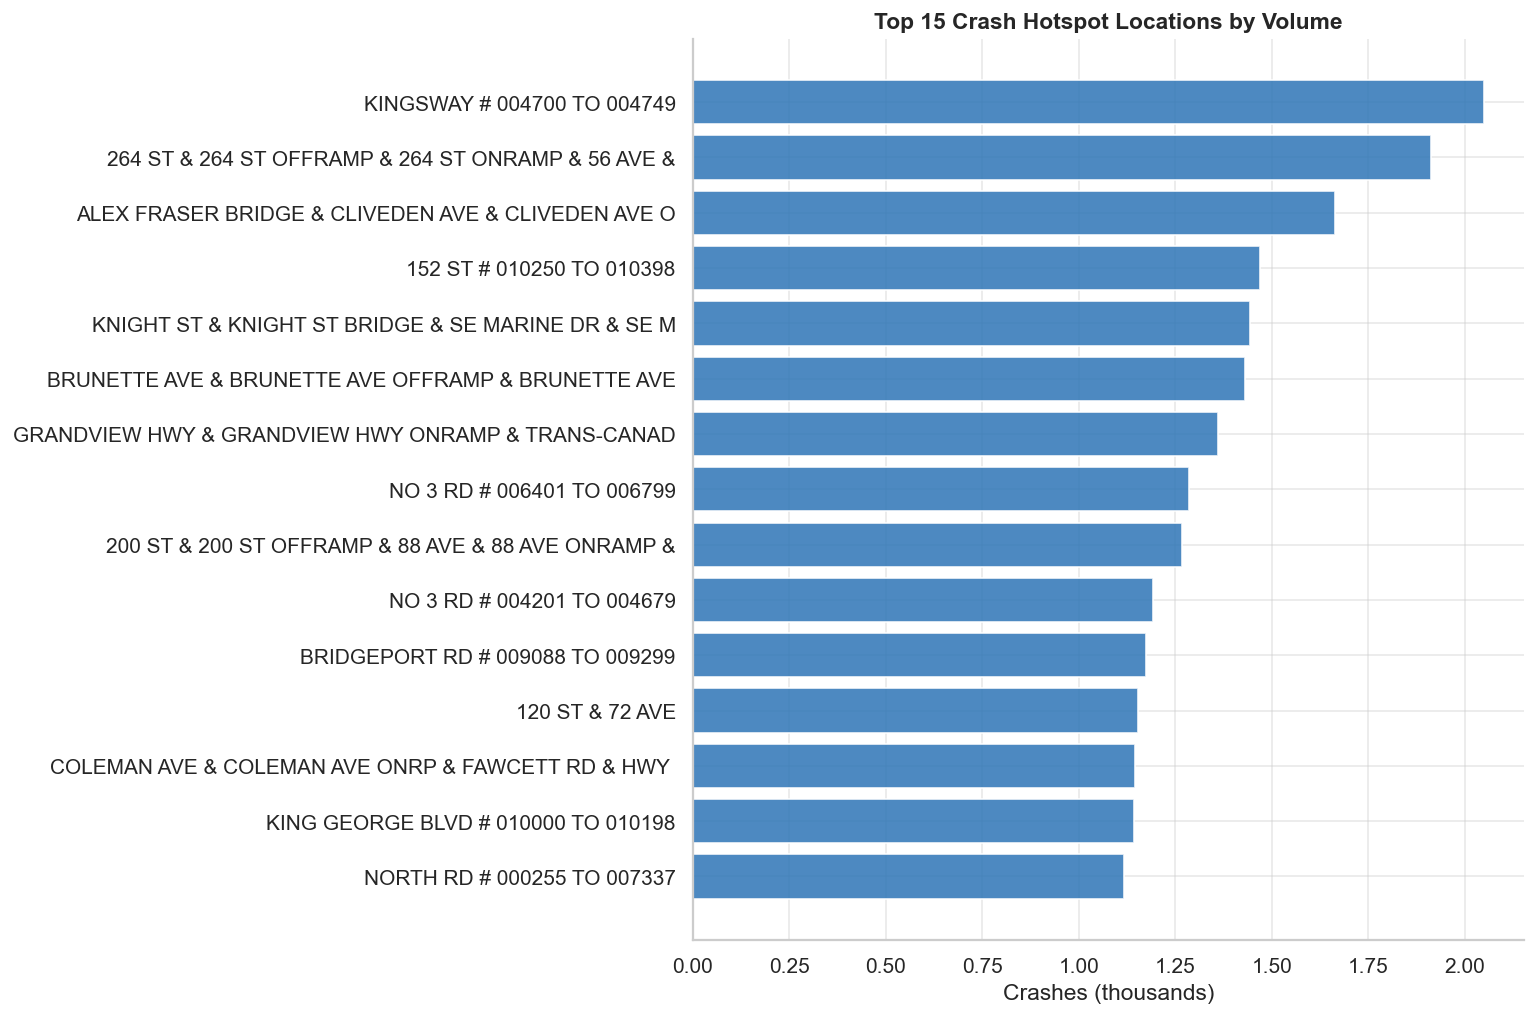

In [312]:
# Top crash locations by volume (exclude UNKNOWN)
fig, ax = plt.subplots(figsize=(12, 8))

hotspot_vol = (df[df["road_location"] != "UNKNOWN"]
               .groupby("road_location").size()
               .nlargest(15).reset_index(name="crashes"))
hotspot_vol["road_location"] = hotspot_vol["road_location"].str[:50]

ax.barh(hotspot_vol["road_location"], hotspot_vol["crashes"]/1000, color=C_BLUE, alpha=0.85)
ax.set_xlabel("Crashes (thousands)")
ax.set_title("Top 15 Crash Hotspot Locations by Volume", fontweight="bold")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rq4_hotspots.png", bbox_inches="tight")
plt.show()

#### Top 15 by Volume:

Kingsway #004700-004749 — busiest single crash corridor in BC at ~2k crashes, a stretch of Kingsway in Vancouver/Burnaby

264 St & Trans-Canada interchange — major highway interchange in Langley

Alex Fraser Bridge & Cliveden Ave — major bridge corridor

Knight St Bridge, Brunette Ave, Grandview Hwy — all major Metro Vancouver arterials/highway connectors

No 3 Rd (Richmond) appears twice — different segments, consistently high crash volume

Pattern: all top locations are highway interchanges or major arterials in Metro Vancouver

---
## 9. Cross-Dimensional Analysis


### 9.1 Road User Type × Hour of Day

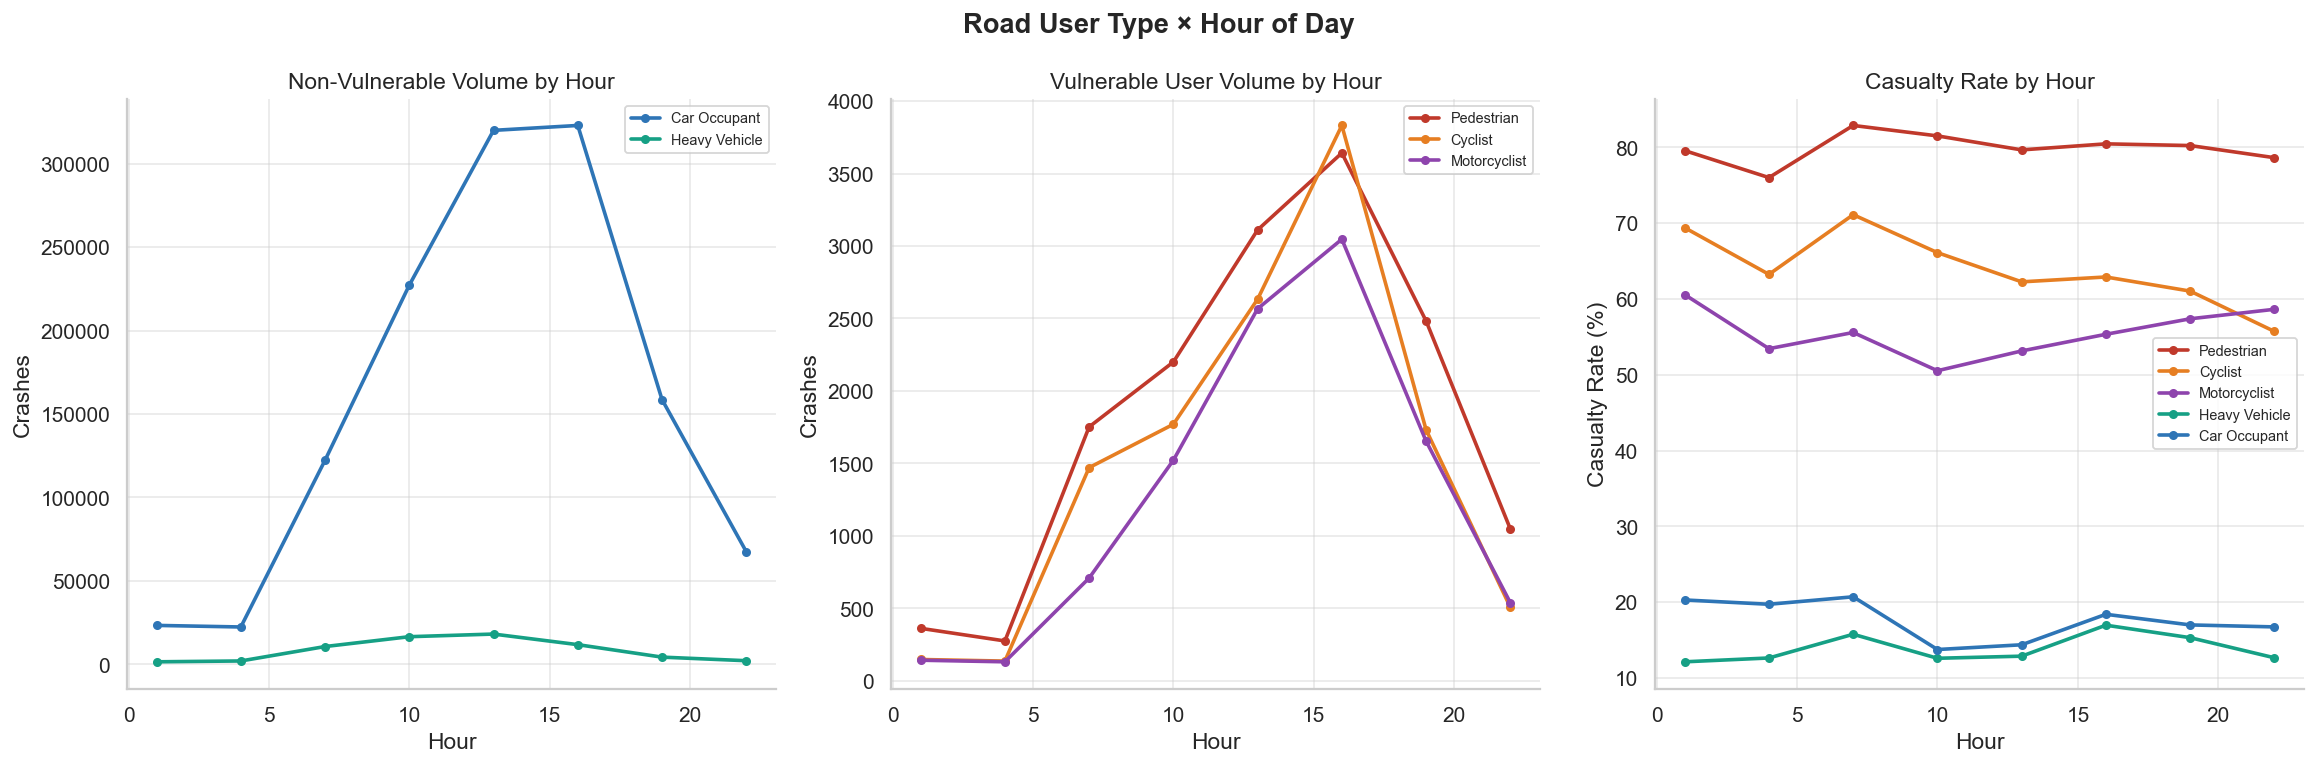

In [316]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Road User Type × Hour of Day", fontweight="bold")

# Panel 1: Car Occupant + Heavy Vehicle
for rut in ["Car Occupant", "Heavy Vehicle"]:
    sub = rh[rh["road_user_type"]==rut]
    axes[0].plot(sub["hour_approx"], sub["count"], marker="o", lw=2, markersize=4,
                 label=rut, color=VULN_PAL.get(rut, C_GREY))
axes[0].set_title("Non-Vulnerable Volume by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Crashes")
axes[0].legend(fontsize=8)

# Panel 2: Vulnerable users only
for rut in ["Pedestrian", "Cyclist", "Motorcyclist"]:
    sub = rh[rh["road_user_type"]==rut]
    axes[1].plot(sub["hour_approx"], sub["count"], marker="o", lw=2, markersize=4,
                 label=rut, color=VULN_PAL.get(rut, C_GREY))
axes[1].set_title("Vulnerable User Volume by Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Crashes")
axes[1].legend(fontsize=8)

# Panel 3: Casualty rate — all groups (unchanged)
for rut in rut_order:
    sub = rh[rh["road_user_type"]==rut]
    axes[2].plot(sub["hour_approx"], sub["rate"], marker="o", lw=2, markersize=4,
                 label=rut, color=VULN_PAL.get(rut, C_GREY))
axes[2].set_title("Casualty Rate by Hour")
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Casualty Rate (%)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cross_rut_hour.png", bbox_inches="tight")
plt.show()


#### Panel 1 — Non-Vulnerable Volume by Hour:

Car Occupant: classic double rush hour peak — 13:00 (\~320k) and 16:00 (\~320k)

Heavy Vehicle: flat and low throughout, slight morning peak at 07:00 — consistent with delivery/logistics schedules

Near zero at 04:00 for both — minimal traffic


#### Panel 2 — Vulnerable User Volume by Hour:

All three groups follow the same shape — near zero at 04:00, build through the day, peak sharply at 16:00

Cyclist and Pedestrian nearly identical peaks at ~3,800 at 16:00 — afternoon rush hour is peak exposure time for both

Motorcyclist peaks at ~3,000 also at 16:00

Sharp drop after 16:00 — by 22:00 pedestrians are at ~1,000, cyclists at ~500, motorcyclists near zero

Morning (07:00) shows a smaller secondary peak for cyclists — commute pattern

#### Panel 3 – Casualty Rate by Hour — all road user types:

Pedestrian (red): remarkably flat at ~80% across ALL hours — no matter what time of day, if a pedestrian is involved it almost always results in injury. Time of day barely matters.

Cyclist (orange): more variation — peaks at 07:00 (~71%), dips midday to \~62%, rises again late night. Morning rush is most dangerous for cyclists

Motorcyclist (purple): dips at 10:00 (\~50%) and rises late night (\~59%) — late night motorcycle crashes are more severe

Car Occupant (blue): peaks at 01:00 (\~21%) and 16:00 (\~21%) — late night and rush hour most dangerous

Heavy Vehicle (teal): lowest throughout, peaks at 07:00 (\~16%) — morning deliveries/rush hour


#### Panels 2 + 3 combined — the critical insight:

Vulnerable users peak in volume at 16:00 (panel 2)

But their casualty rate is flat all day (panel 3, pedestrian ~80%, cyclist ~62-71%)

This means 16:00 produces the most absolute vulnerable user casualties — highest exposure AND sustained high rate

Late night (01:00) has low vulnerable user volume but high rate — fewer crashes but more severe


**Results:** Vulnerable user crash volume peaks sharply at 16:00 (afternoon rush) for all three groups, aligned with car occupant traffic peaks. However unlike car occupants whose casualty rate varies by hour, pedestrian rates remain near-constant (~80%) throughout the day — confirming that pedestrian injury risk is driven by structural road design rather than behavioural or temporal factors. The 16:00 hour represents the highest absolute risk window for vulnerable user casualties due to the combination of peak exposure and sustained high injury rates.

### 9.2 Road User Type × Season

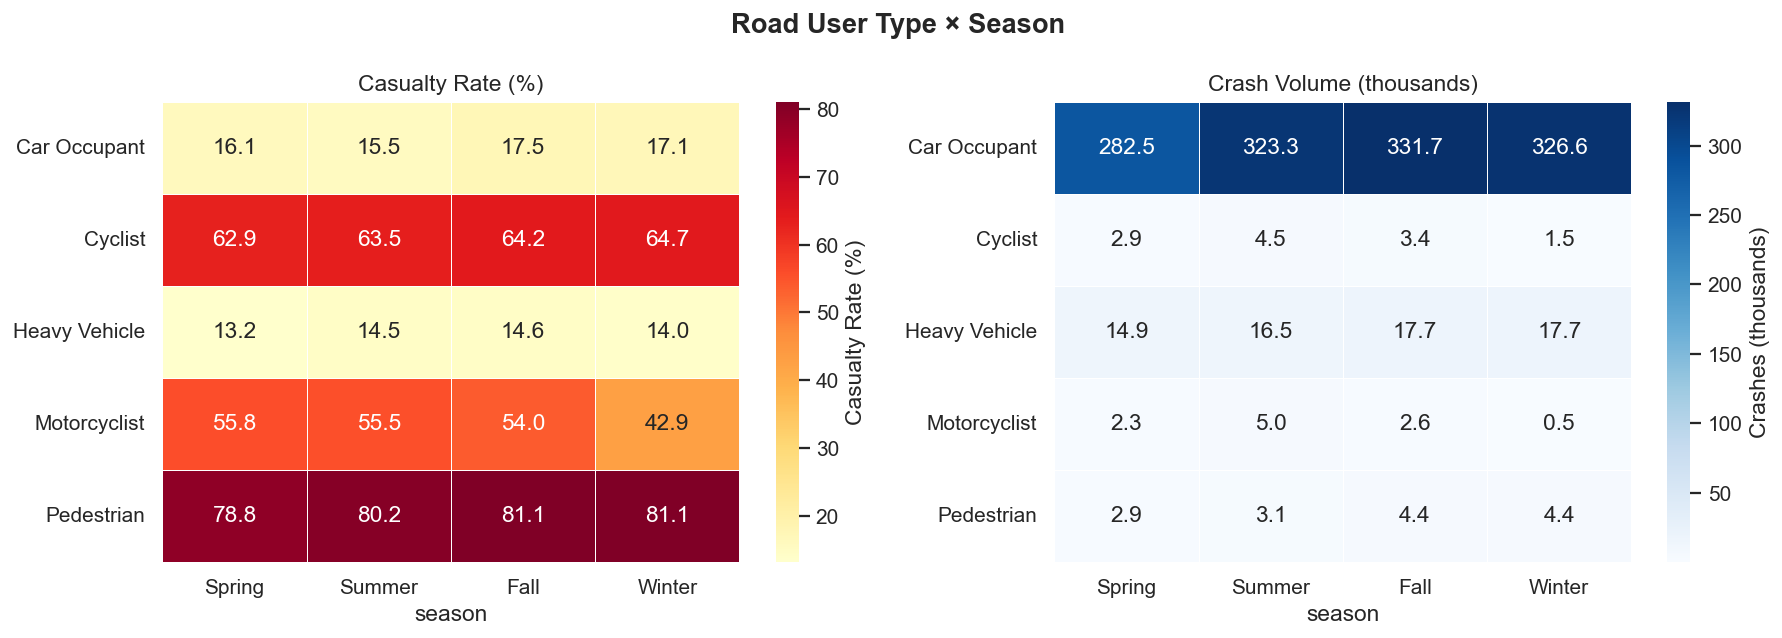

In [202]:
rs = (df.groupby(["road_user_type","season"])["is_casualty"]
      .agg(["sum","count"])
      .assign(rate=lambda x: x["sum"]/x["count"]*100)
      .reset_index())

heat_rs = (rs.pivot(index="road_user_type", columns="season", values="rate")
           .reindex(columns=season_order))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Road User Type × Season", fontweight="bold")

sns.heatmap(heat_rs, cmap="YlOrRd", ax=axes[0], annot=True, fmt=".1f",
            cbar_kws={"label":"Casualty Rate (%)"}, linewidths=0.5)
axes[0].set_title("Casualty Rate (%)")
axes[0].set_ylabel("")

vol_rs = rs.pivot(index="road_user_type", columns="season", values="count").reindex(columns=season_order)
sns.heatmap(vol_rs/1000, cmap="Blues", ax=axes[1], annot=True, fmt=".1f",
            cbar_kws={"label":"Crashes (thousands)"}, linewidths=0.5)
axes[1].set_title("Crash Volume (thousands)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cross_rut_season.png", bbox_inches="tight")
plt.show()


#### Left — Casualty Rate (%) by Road User × Season:

Pedestrian: 78.8 → 81.1 → 81.1 — virtually flat across all seasons. Confirms again: pedestrian risk is structural, not seasonal

Cyclist: 62.9 → 63.5 → 64.2 → 64.7 — slight upward trend toward winter, but remarkably stable. Cyclists who crash in any season are almost always injured

Motorcyclist: Most seasonal variation of any group — 55.8 (Spring) → 55.5 (Summer) → 54.0 (Fall) → 42.9 (Winter). Winter motorcycle crashes are notably less severe — likely because very few people ride motorcycles in winter, so those who do are experienced riders on clear days

Car Occupant: 16.1 → 15.5 → 17.5 → 17.1 — slight fall/winter increase, consistent with adverse conditions

Heavy Vehicle: Flat ~13-14% all year — most stable group


#### Right — Crash Volume by Road User × Season:

Car Occupant dominates — 282k to 331k, peaks in Fall

Cyclist: Summer 4.5k vs Winter 1.5k — 3× more cyclists in summer, massive seasonal swing

Motorcyclist: Summer 5.0k vs Winter 0.5k — 10× more motorcyclists in summer. Most extreme seasonality of any group

Pedestrian: Spring/Summer ~3k, Fall/Winter ~4.4k — counterintuitively MORE pedestrian crashes in fall/winter despite less pleasant weather. Likely due to reduced visibility (darkness), wet surfaces, and more pedestrians using transit/walking in urban areas during colder months

Heavy Vehicle: Relatively flat, slight fall/winter increase


**The motorcyclists — combining both heatmaps:**

Winter volume: 0.5k (almost nobody rides)

Winter casualty rate: 42.9% (lowest of any season)

Summer volume: 5.0k (10× more riders)

Summer casualty rate: 55.5%

Interpretation: Winter motorcyclists are a self-selected group of experienced riders on good days. Summer brings casual/inexperienced riders who crash more severely.


**Results:** The Road User × Season heatmap reveals starkly different seasonal patterns by group. Cyclists and motorcyclists show extreme volume seasonality (3× and 10× summer vs winter respectively) while pedestrian volumes are counter-seasonally elevated in fall/winter — likely due to reduced visibility and more urban walking. Pedestrian casualty rates remain near-constant across all seasons (~79–81%), the strongest evidence yet that pedestrian injury risk is infrastructure-driven rather than weather or behavioural. The motorcyclist winter paradox — lowest volume AND lowest casualty rate — suggests experienced rider self-selection in adverse conditions.

### 9.3 Intersection vs Non-Intersection by Road User Type

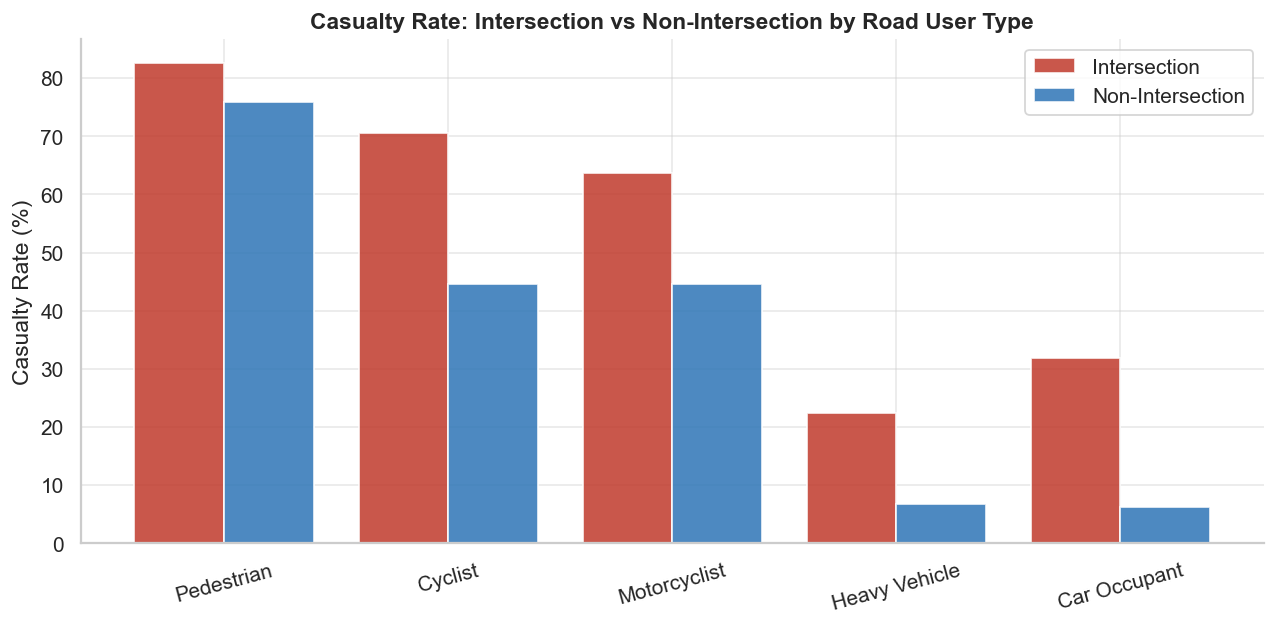

In [204]:
ri = (df.groupby(["road_user_type","intersection"])["is_casualty"]
      .agg(["sum","count"])
      .assign(rate=lambda x: x["sum"]/x["count"]*100)
      .reset_index())

ri_int = ri[ri["intersection"]==1].set_index("road_user_type")["rate"]
ri_non = ri[ri["intersection"]==0].set_index("road_user_type")["rate"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rut_order))
ax.bar(x-0.2, [ri_int.get(r, 0) for r in rut_order], 0.4, color=C_RED, alpha=0.85, label="Intersection")
ax.bar(x+0.2, [ri_non.get(r, 0) for r in rut_order], 0.4, color=C_BLUE, alpha=0.85, label="Non-Intersection")
ax.set_xticks(x); ax.set_xticklabels(rut_order, rotation=15)
ax.set_ylabel("Casualty Rate (%)")
ax.set_title("Casualty Rate: Intersection vs Non-Intersection by Road User Type", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cross_intersection_rut.png", bbox_inches="tight")
plt.show()


#### Key Findings — Intersection vs Non-Intersection by Road User Type

| Group | Intersection | Non-Intersection | Gap |
|-------|-------------|-----------------|-----|
| Pedestrian | 83% | 76% | +7pp |
| Cyclist | 71% | 45% | **+26pp** |
| Motorcyclist | 64% | 45% | **+19pp** |
| Heavy Vehicle | 23% | 7% | +16pp |
| Car Occupant | 32% | 6% | **+26pp** |

**Key takeaways:**
- **Pedestrian risk is location-invariant (smallest gap)** — Pedestrians are nearly equally at risk at intersections AND non-intersections (83% vs 76%). Confirms again — pedestrian risk is everywhere, not concentrated at one location type.
- **Cyclists face the largest vulnerable-user intersection penalty (+26pp)** — Intersection crashes are far more dangerous for cyclists (71%) than mid-block crashes (45%). Likely due to vehicle turning conflicts at intersections — the classic "right hook" scenario.
- **Motorcyclists show a similar pattern (+19pp)** — Similar story to cyclists — intersection conflicts are significantly more deadly.
- **Car occupants have the most dramatic gap (+26pp)** — Intersection crashes (32%) vs non-intersection (6%). Non-intersection car crashes are almost all parking lot fender-benders — harmless. Intersection car crashes involve speed and perpendicular impacts.
- **Heavy Vehicle (16pp)** – Intersection crashes are 3× more dangerous than non-intersection for heavy vehicles too.

**Results** – Intersections amplify casualty risk for every road user type, but disproportionately for cyclists (+26pp gap) and motorcyclists (+19pp). This is consistent with turning conflict risk — vehicles making turns at intersections pose the greatest threat to cyclists and motorcyclists who are less visible. Pedestrians show the smallest intersection effect (+7pp), reinforcing that their risk is distributed across all road environments rather than concentrated at conflict points. This finding directly supports investment in protected intersection design as a priority intervention for vulnerable user safety.


### 9.4 Casualty Rate Heatmap — Year × Season

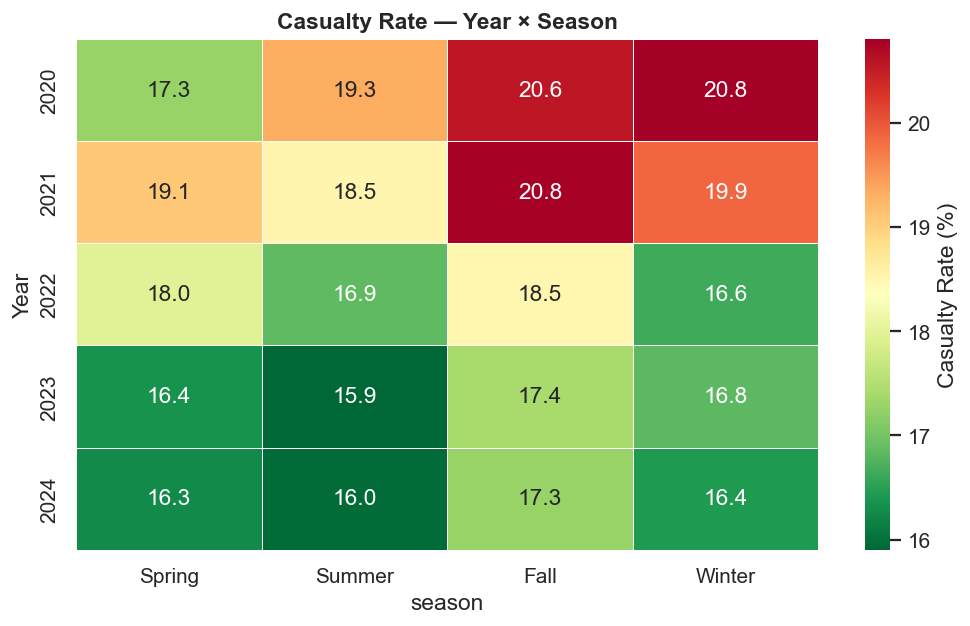

In [206]:
ys = (df.groupby(["year","season"])["is_casualty"]
      .agg(["sum","count"])
      .assign(rate=lambda x: x["sum"]/x["count"]*100)
      .reset_index()
      .pivot(index="year", columns="season", values="rate")
      .reindex(columns=season_order))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ys, cmap="RdYlGn_r", annot=True, fmt=".1f", ax=ax,
            linewidths=0.5, cbar_kws={"label":"Casualty Rate (%)"})
ax.set_title("Casualty Rate — Year × Season", fontweight="bold")
ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cross_year_season.png", bbox_inches="tight")
plt.show()


#### Key Findings — Casualty Rate: Year × Season

**The overall trend is improvement** — the entire heatmap shifts from red/orange (2020–2021)
to green (2023–2024). Every season improved year-over-year, which is encouraging.

**2020 and 2021 stand out as the most dangerous years:**
- 2020 Fall (20.6%) and Winter (20.8%) are the darkest red cells in the entire grid
- 2021 Fall (20.8%) matches 2020's worst — the post-COVID traffic rebound brought
  back volume without immediately improving safety outcomes
- 2020 Spring (17.3%) is the one exception — COVID lockdowns reduced traffic and
  likely eliminated the most dangerous driving behaviours (commuting, impairment)

**Fall is consistently the most dangerous season across all years:**
- Fall is the highest or joint-highest casualty rate in every single year
- Even in 2024 (the safest year overall), Fall (17.3%) is still the peak season
- This is a structural seasonal pattern, not an anomaly

**Summer improved the most dramatically:**
- 2020 Summer: 19.3% → 2024 Summer: 16.0% — a 3.3pp improvement
- Summer 2023 and 2024 are the two greenest cells in the grid
- Likely reflects more urban low-speed driving post-COVID replacing highway driving

**2022 is an interesting inflection point:**
- Rates dropped sharply from 2021 to 2022 across all seasons
- This is where the improvement trend begins — possibly reflecting road safety
  initiatives, increased speed enforcement, or changes in driving patterns

**Note on 2020 baseline:** The relatively low Spring 2020 rate (17.3%) coincides with
COVID lockdowns (March–May 2020). Reduced traffic volume and fewer commuters on the
road temporarily suppressed casualty rates before rebounding in Fall/Winter 2020
when traffic returned but driving behaviour had not yet adjusted.

### 9.5 Vulnerable-User Crashes by Year and Season

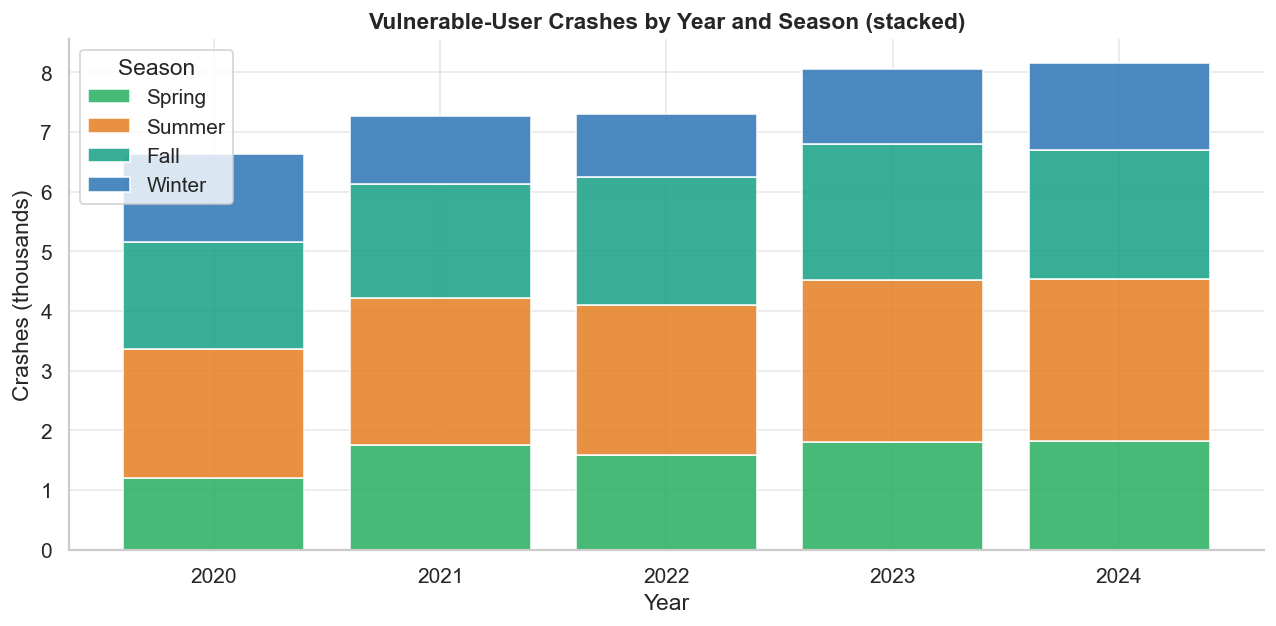

In [208]:
vuln_ys = (df[df["is_vulnerable"]==1]
           .groupby(["year","season"]).size()
           .reset_index(name="count")
           .pivot(index="year", columns="season", values="count")
           .reindex(columns=season_order).fillna(0))

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(vuln_ys))
pal = {"Spring": C_GREEN, "Summer": C_ORANGE, "Fall": C_TEAL, "Winter": C_BLUE}
for season in season_order:
    vals = vuln_ys[season].values
    ax.bar(vuln_ys.index.astype(int), vals/1000, bottom=bottom/1000, label=season,
           color=pal[season], alpha=0.85)
    bottom += vals
ax.set_title("Vulnerable-User Crashes by Year and Season (stacked)", fontweight="bold")
ax.set_ylabel("Crashes (thousands)")
ax.set_xlabel("Year")
ax.legend(title="Season")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cross_vuln_year_season.png", bbox_inches="tight")
plt.show()


#### Key Findings — Vulnerable-User Crashes by Year and Season (Stacked)

**Total vulnerable-user crashes are growing year-over-year:**
- 2020: ~6.6k → 2021: ~7.3k → 2022: ~7.3k → 2023: ~8.0k → 2024: ~8.2k
- A **24% increase** from 2020 to 2024 — nearly 1,600 more vulnerable users
  being involved in crashes annually compared to the start of the period
- 2022 was a plateau year — no growth from 2021 — before resuming upward in 2023

**Summer (orange) is consistently the largest seasonal contributor:**
- Summer dominates in every year, accounting for roughly 35–40% of annual
  vulnerable user crashes
- The Summer block grew noticeably from 2022 to 2023/2024 — more cyclists
  and pedestrians active post-COVID urban recovery

**Fall (teal) is the second largest and also growing:**
- Fall grew substantially from ~1.8k (2020) to ~2.2k (2024)
- Combined with Summer, these two seasons account for roughly 65% of all
  vulnerable user crashes in any given year

**Winter (blue) is growing the fastest proportionally:**
- 2020 Winter: ~1.4k → 2024 Winter: ~1.6k
- The Winter block is visually larger in 2023 and 2024 compared to earlier years
- More vulnerable users on roads year-round — likely reflecting increased
  active transportation adoption even in colder months

**Spring (green) remains the smallest and most stable contributor:**
- Consistently ~1.2–1.9k across all years with modest growth
- Spring's relative stability suggests the seasonal uptick in active
  transportation is concentrated in Summer rather than spread evenly

**Cross-referencing with the Year × Season casualty rate heatmap:**
- Vulnerable user crash *volumes* are rising (this chart)
- Overall casualty *rates* are declining (previous heatmap)
- These two trends partially offset each other — more crashes but each
  individually slightly less likely to be severe. However the net outcome
  is still more total vulnerable user casualties year-over-year.

---
## 10. Summary of Key Findings

| RQ | Section | Finding |
|----|---------|---------|
| RQ1 | Year | Total crashes rose 36% (2020–2024) driven by PDO growth; casualty crashes remained flat; overall casualty rate declined from 20% → 16.5% |
| RQ1 | Month | December peaks in volume; fall/winter months consistently above-average casualty rates; April lowest volume |
| RQ1 | Season | Crash volume is nearly uniform across seasons; summer has the most vulnerable-user crashes; fall has the highest casualty rates |
| RQ1 | Day | Weekdays dominate volume and have *higher* casualty rates than weekends — opposite of conventional wisdom |
| RQ1 | Hour | Rush hours (13:00–16:00) dominate absolute casualties; late-night (01:00–04:00) and weekday morning rush (07:00) have the highest casualty *rates* (~22–23%) |
| RQ1 | Heatmap | Weekend late night (Sat/Sun 01:00) is the single most dangerous hour×day combination — low volume, ~23% casualty rate, strongly suggesting impairment |
| RQ1 | Config | Rear-end (35%) and head-on (30%) configurations have the highest casualty rates; single vehicle is the most common crash type but below-average severity |
| RQ1 | Flags | Pedestrian involvement is the strongest severity predictor — raises casualty rate from 17% to 80.5%; intersection crashes carry 33% casualty rate vs 7% non-intersection |
| RQ3 | Profile | Pedestrian 80.5%, Cyclist 63.7%, Motorcyclist 54.6% vs Car Occupant 16.6% — vulnerable users face 3–5× higher casualty rates |
| RQ3 | Gap | The vulnerability gap is widening — absolute gap grew from 49pp to 54pp (2020–2024); relative gap from 3.6× to 4.6× |
| RQ3 | RII | Pedestrian RII rose from 4.20 → 5.44 (+29%); Cyclist from 3.29 → 4.42 (+34%); Heavy Vehicle consistently below 1.0 (safer than car occupants) |
| RQ3 | Volume | All vulnerable user groups grew 20–30% in crash volume 2020–2024; car occupants grew 34% but became safer — road safety improvements favour vehicle occupants |
| RQ4 | Volume | Vancouver (220k), Surrey (158k), Burnaby (83k) dominate absolute crash counts — all Metro Vancouver |
| RQ4 | Rate | Smaller municipalities (Spallumcheen 30.6%, View Royal 27.7%) have the highest casualty rates — rate and count tell completely different stories |
| RQ4 | Vulnerable rate | View Royal leads at 83.3% vulnerable-user casualty rate; Surrey (73.9%) is most concerning — high volume AND high vulnerable rate |
| RQ4 | Composition | Vancouver's vulnerable problem is cyclists (\~45%); Surrey's is pedestrians (~60%) — different compositions require different policy responses |
| RQ4 | Hotspots | Kingsway is the highest-volume single crash corridor in BC; all top-15 locations are highway interchanges or major arterials in Metro Vancouver |
| Cross | Hour×RUT | Pedestrian casualty rate is flat across all hours (~80%) — structural risk; cyclist rate peaks at 07:00 morning rush; all vulnerable users peak in volume at 16:00 |
| Cross | Season×RUT | Motorcyclists show 10× more crashes in summer than winter; pedestrian rates near-constant year-round (78–81%) — further evidence of structural risk |
| Cross | Intersection×RUT | Intersections disproportionately affect cyclists (+26pp) and motorcyclists (+19pp); pedestrians show smallest intersection penalty (+7pp) |
| Cross | Year×Season | Entire heatmap improved from red (2020–2021) to green (2023–2024); fall is consistently the most dangerous season in every year |

*Next: modelling to quantify feature contributions to casualty risk.*
